# 1. Settings and preparations

## 1.1 Packages

In [1]:
import os, pathlib, itertools, pickle, warnings
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import pandas as pd
import scipy as sc
from sklearn import svm

## 1.2 Settings

### 1.2.1 Running Settings

In [ ]:
# specific settings for permutation test (2.1.1 & 2.1.2)
perform_new_permutation = False   # determine whether new permutations should be conducted for each subject (True) or loaded from disk (False) 
save_permutation_results = False    # determine whether permutation results should be stored
permutation_runs = 5000

# settings for generative cross-validation and generalisation tests (2.2.1 - 2.2.3)
compute_new_subject_results = True    # determine whether subjects should be (re-)analyzed (True) or loaded from disk (False) 
perform_new_cross_validation = True     # determine whether group cross-validation results should be recomputed (True) or loaded from disk (False) 
perform_new_generalisation = True        # determine whether group generalisation results should be recomputed (True) or loaded from disk (False)
use_saved_classifiers = False       # determine whether to use classifiers from general cross-validation (True) or train new classifiers (False)

# save results
save_subject_results = False            # determine whether subjectwise results should be stored 
save_group_results = False              # determine whether grouptwise results should be stored 

### 1.2.2 General Settings

In [ ]:
# defines whether PoTJs should be z-standardized for machine learning analysis (original values will not be overwritten)
z_standardisation = True

# set seed for numpy random generator
random_seed = 42

# Determine how to deal with warnings (ignore, hold)
# warning_effect = "hold" # "ignore", "default"

# Should missing correlation (e.g. due to constant input) be saved as 0 or nan
missing_correlation_entry = 0 # missing_correlation_entry = np.nan

# should a warning message be printed for every failed correlation computation?
print_missingcorr_warning = False

# perform alpha error threshold correction for t-tests of individual training sets
alpha_correction = True

# condition level naming
velocity_level_label = ["still", "slow", "fast"]
density_level_label = ["few", "many"]

# save figures as pdf and/or png?
save_as_pdf = True
save_as_png = True

# prepare random generator
rng = np.random.default_rng(random_seed)

### 1.2.3 Plotting Settings

In [5]:
# should plots be displayed in separate windows? The excecution of the script is interupted while a figure window is open. 
separate_plot_windows = False


# --------------------------------------------------
# General predictability test
show_subjectwise_prediction_plots = True
save_subjectwise_prediction_plots = False

# Plot of average prediction performance over all subjects
show_average_prediction_plots = True
save_average_prediction_plots = False

# Plot prediction results vs. permutation results
show_predictionvspermutation_plots = True
save_predictionvspermutation_plots = True


# --------------------------------------------------
# Cross-Validation plots

# Plot cross-validations for each training-set
show_validation_setwise_plots = True
save_validation_setwise_plots = False

# Plot validations averaged over all training sets
show_validation_average_plots = True
save_validation_average_plots = False


# --------------------------------------------------
# Generalisation plots

# Plot Generalisations for each combination of training and test set
show_generalisation_pairwise_plots = True
save_generalisation_pairwise_plots = False

# Plot generalisation for each training set
show_generalisation_setwise_plots = True
save_generalisation_setwise_plots = False

# Plot generalisation averaged over all training sets
show_generalisation_average_plots = True
save_generalisation_average_plots = False


# --------------------------------------------------
# Combined Validation - Generalisation plots

show_validation_generalisation_plots = True
save_validation_generalisation_plots = True


# --------------------------------------------------
# Subjectwise behavioral plots

show_subjectwise_behavioral_plots = True
save_subjectwise_behavioral_plots = False



# --------------------------------------------------
# General plotting settings 

# space between subplots
wspace = 0.3
hspace = 0.3

# violin and boxplots vertical?
vertical_plots = False
reversed_yaxis = True

plot_offsetts = .7

# Connect participants cross-validation to generalisation and between sets
connect_analyses = True
connect_sets = False


# determine whether plots should be displayed in separate windows
if separate_plot_windows:
    import matplotlib
    matplotlib.use('Qt5Agg')

## 1.3 Directories

In [ ]:
# path to all study data
path_study_data = pathlib.Path("D:/EEGST data/")

# Folder containing sourcedata (behavioral data, demografic data, montages)
path_sourcedata = path_study_data / 'bids_dataset' / 'sourcedata'

# path to preprocessing folder
path_data_preprocessing =  path_study_data / 'preprocessing'

# path to general subject wise analysis folder
path_data_analysis =  path_study_data / 'analysis'
# Create folder if they do not yet exist
if not os.path.isdir(path_data_analysis):
    os.mkdir(path_data_analysis)
    
# path to group level analysis data folder
path_data_grouplevel =  path_study_data / 'group_level'

## 1.4 Functions

### 1.4.1 Helper functions

#### 1.4.1.1 set_warnings()

In [7]:
def set_warnings(warning_effect = "default"):
    """
    Set the behavior for warning messages during code execution.

    Args:
        warning_effect (str): Determines warning behavior. 
            - "hold": Raises warnings as errors (halts execution).
            - "ignore": Suppresses all warnings.
            - "default": Resets to default warning behavior.

    Returns:
        None
    """

    # hold and catch fire in case of warning (exception: ConstantInputWarnings during correlation computation)
    if warning_effect == "hold":
        warnings.filterwarnings("error")
    # ignore warnings and dont print any message
    elif warning_effect == "ignore":
        warnings.filterwarnings("ignore")
    # default: continue with code but print warning message
    elif warning_effect == "default":
        warnings.resetwarnings()
        
        
        
    warnings.filterwarnings("ignore", "is_categorical_dtype")

#### 1.4.1.2 get_subject_list()

In [ ]:
def get_subject_list(use_raw_demodata = False, exclude_subjects = True, single_group = "controls", selection = []):
    """
    Retrieve a list of subject IDs from demographic data based on filtering criteria.

    Args:
        use_raw_demodata (bool): If True, load raw demographic data. If False, use preprocessed data.
        exclude_subjects (bool): If True, exclude subjects not marked as included.
        single_group (str): Filter to a specific group. Use "controls" for group 1 or "patients" for group 2.
        selection (list[int]): Optional list of subject IDs to include. If provided, only these subjects are returned.

    Returns:
        list[int]: List of subject IDs that meet the specified criteria.
    """
    
    # Load either raw or preprocessed demografic data
    if use_raw_demodata:
        demo_data = pd.read_csv(path_sourcedata / 'demografic_data.csv', encoding='latin-1', sep=";")
    else:
        demo_data = pd.read_csv(pathlib.Path(path_data_grouplevel / 'demografic_availabledata.csv'), encoding='cp1252')

    # only keep subjects from specific group
    if single_group == "controls":
        demo_data = demo_data[demo_data.group == 1]
    elif single_group == "patients":
        demo_data = demo_data[demo_data.group == 2]

    # only keep subjects not marked as excluded
    if exclude_subjects:
        demo_data = demo_data[demo_data.included]

    # extract subject names
    subjects = [int(subject["subject"]) for _ , subject in demo_data.iterrows()]

    if selection:
        subjects = [subject for subject in subjects if subject in selection] 

    return(subjects)

#### 1.4.1.3 get_subject_data_paths()

In [9]:
def get_subject_data_paths(subject):
    """
    Get input and output data paths for a given subject.

    Args:
        subject (int or str): Subject identifier.

    Returns:
        tuple: (path_data_preprocessing_subj, path_data_analysis_subj)
            - path_data_preprocessing_subj (Path): Path to subject's preprocessing data.
            - path_data_analysis_subj (Path): Path to subject's analysis data.
    """  
    
    # add leading zeros for one- and two-digit numbers    
    subject = str(subject).zfill(3)
    
    # data folder (input)
    path_data_preprocessing_subj = path_data_preprocessing / subject
    
    # analysis folder (output)
    path_data_analysis_subj = path_data_analysis / subject
    
    # Create folder if it does not yet exist
    if not os.path.isdir(path_data_analysis_subj):
        os.mkdir(path_data_analysis_subj)
        
    subj_paths = [path_data_preprocessing_subj, path_data_analysis_subj]
        
    return(subj_paths)

#### 1.4.1.4 try_correlation()

In [10]:
def try_correlation(x, y, missing_correlation_entry = missing_correlation_entry):
    """
    Compute Pearson correlation between two arrays, handling constant input gracefully.

    Args:
        x (array-like): First input array.
        y (array-like): Second input array.
        missing_correlation_entry (float, optional): Value to use if correlation cannot be computed due to constant input.

    Returns:
        float: Pearson correlation coefficient or missing_correlation_entry if not computable.

    Raises:
        Exception: If correlation fails for reasons other than constant input.
    """
    
    # change the warning effect to 'hold' to be able to catch it (and ignore it, if it was caused by constant input arrays)
    set_warnings(warning_effect = "hold")

    # Try to compute the correlation between predicted and true values                    
    try:
        corr, _ = sc.stats.pearsonr(x, y)
            
    # if correlation computation fails
    except Exception as error:
            
        # if the correlation failed due to constant input, continue with specified message and substitute missing correlation  
        if str(error) == "An input array is constant; the correlation coefficient is not defined.":
            
            if print_missingcorr_warning:
                print(f"Correlation failed due to constant input, substituting with '{missing_correlation_entry}'")
            corr = np.nan
        # if the correlation fails for any other reason, hold and catch fire
        else:
            raise Exception(f"Correlation failed: {error}")
    
    # turn warnings back to default
    set_warnings(warning_effect = "default")
        
    return(corr) 

#### 1.4.1.5 stats_to_str()

In [11]:
def stats_to_str(stats, nr_of_comparissons = 1):
    """
    Format t-test statistics as a readable string.

    Args:
        stats (scipy.stats object): T-test result object.
        nr_of_comparissons (int): Number of comparisons for alpha correction.

    Returns:
        str: Formatted statistics string.
    """
    
    alpha_thresholds = [0.05, 0.01, 0.001]
    alpha_thresholds = [threshold / nr_of_comparissons for threshold in alpha_thresholds]
    
    if stats.pvalue < alpha_thresholds[2]:
        significance_marker = "***"
    elif stats.pvalue < alpha_thresholds[1]:
        significance_marker = "**" 
    elif stats.pvalue < alpha_thresholds[0]:
        significance_marker = "*"  
    else:
        significance_marker = "(n.s.)"

    if stats.pvalue < 0.001:
        pvalue_text = f"p < 0.001"
    else:
        pvalue_text = f"p = {np.round(stats.pvalue, 3)}"

    # add t-test statistics for cumulative zs (over all sets from all participants)
    stats_str = f"t({stats.df}) = {np.round(stats.statistic, 3)}, {pvalue_text} {significance_marker}"
    
    return(stats_str)

#### 1.4.1.6 create_setlabels()

In [12]:
def create_setlabels(set_conditions):
    """
    Create human-readable labels for condition sets.

    Args:
        set_conditions (pd.DataFrame): DataFrame with 'condition' and 'levels' columns.

    Returns:
        list: List of string labels for each set.
    """
    
    set_list = []
    for _, set in set_conditions.iterrows():
        
        # Add subplot title containing set conditions
        lable = ""
        for _, set_levels in zip(set["condition"], set["levels"]):
            
            if len(lable) > 0:
                lable += " / "
            if set_levels.__class__ == list:
                set_levels = ",".join(str(elem) for elem in set_levels)
            lable += f"{set_levels}"
            
        set_list.append(lable)
        
    return(set_list)

#### 1.4.1.7 zbacktransform() & zbacktransform_group()

In [13]:
def zbacktransform(zvalues, subject):
    """
    Back-transform z-standardized values to original scale for a subject.

    Args:
        zvalues (float or list): Z-standardized values.
        subject (int or str): Subject identifier.

    Returns:
        float or list: Values on the original scale.
    """
    
    # get path to subject data and output folders
    path_data_preprocessing_subj, _ = get_subject_data_paths(subject)
    
    # load epoch features
    subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
    
    # get subject mean and sd
    subject_mean = np.mean(subject_df["potj"])
    subject_sds = np.std(subject_df["potj"])
    
    # back transform
    if isinstance(zvalues, list):
        back_transformed = [((zvalue * subject_sds) + subject_mean) for zvalue in zvalues]
    else:
        back_transformed = ((zvalues * subject_sds) + subject_mean)
    
    return(back_transformed)
    

def zbacktransform_group(subjects, zvalues, new_transformation = False, save_values = False):
    """
    Back-transform group z-standardized values to original scale.

    Args:
        subjects (list): List of subject identifiers.
        zvalues (list): Z-standardized values for the group.
        new_transformation (bool): If True, recompute group means/SDs.
        save_values (bool): If True, save computed means/SDs.

    Returns:
        list: Back-transformed values.
    """
    # loop through participants and retrieve means and sds for each participant
    if new_transformation:
    
        group_means, group_sds = [], []
        for _, subject in enumerate(subjects):
            
            # get path to subject data and output folders
            path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)
            
            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
            group_means.append(np.mean(subject_df["potj"]))
            group_sds.appen(np.std(subject_df["potj"]))
        
        groupstats = {"means": group_means,
                      "sds": group_sds}
        
        # save group stats
        if save_values:
            with open(path_study_data / 'group_level' / 'ztransformation_values.pkl', 'wb') as f:
                pickle.dump(groupstats, f)
    
    # load stored group stats            
    else:
        with open(path_study_data / 'group_level' / 'ztransformation_values.pkl', 'rb') as f:
            groupstats = pickle.load(f)
            
    back_transformed = [((zvalue * groupstats["sds"][zvalue_nr]) + groupstats["means"][zvalue_nr]) for zvalue_nr, zvalue in enumerate(zvalues)]
    
    return(back_transformed)  

### 1.4.2 Analysis functions

#### 1.4.2.1 crossval_general()

In [14]:
def crossval_general(subjects, compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results):  

    """
    Perform five-fold cross-validation for each subject and return correlation results.
    The function divides each participants data into five folds so that each fold contains equal amounts of data (max 20%) from each condition combination.
    For each subject, each combination of 4 out of the 5 folds is then used once as a training set with the fifth set as the test set respectively.
    For each subject, the classifiers predictions for all five test-sets are then correlated against the true values.

    Args:
        subjects (list): List of subject identifiers.
        compute_new_subject_results (bool): Whether to recompute subject results.
        save_subject_results (bool): Whether to save subject results.
        save_group_results (bool): Whether to save group results.

    Returns:
        list: Correlation coefficients for each subject.
    """ 
    
    subjectwise_corrs = []
    for _, subject in enumerate(subjects):
        
        # get path to subject data and output folders
        path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)
        
        if compute_new_subject_results:
            
            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
            # turn velocity and density in categorical variables
            subject_df['velocity'] = subject_df['velocity'].astype("category")
            subject_df['density'] = subject_df['density'].astype("category")

            # change label names
            subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
            subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})
            
            # z-standarizate PoTJ values per participant?
            if z_standardisation:
                subject_df["potj"] = sc.stats.zscore(subject_df["potj"])
            
            # separate starfield data (eliminate all rs data)
            rs_indices = [index for index, row in subject_df.iterrows() if row["condition"] == "rs_start"]
            data_starfield = subject_df.drop(index = rs_indices)
            
            # determine fold size based on smallest condition
            smallest_condition = np.min(data_starfield.groupby(['velocity', 'density'], observed = True).size())
            condition_per_fold = smallest_condition // 5
            
            # build 5 fold of data
            folds = {"1": pd.DataFrame(),
                    "2": pd.DataFrame(),
                    "3": pd.DataFrame(),
                    "4": pd.DataFrame(),
                    "5": pd.DataFrame()}
            
            # table of unique condition combinations
            condition_combinations = pd.DataFrame(itertools.product(np.unique(data_starfield['velocity']), np.unique(data_starfield['density'])), columns = ["velocity", "density"])
            
            # cicle through all conditions and split data from each condition into 5 folds
            for _, condition_row in condition_combinations.iterrows():
            
                # split data according to conditions
                condition_indices = [data_index for data_index, data_row in subject_df.iterrows() if (data_row["velocity"] == condition_row["velocity"] and data_row["density"] == condition_row["density"])]
                condition_data = subject_df.iloc[condition_indices,]

                # shuffle data
                index_list = list(range(condition_per_fold * 5))
                #random.shuffle(index_list)
                rng.shuffle(index_list)
            
                # distribute data from current condition over the 5 folds
                for fold_nr, fold in enumerate(folds):
                    condition_fold_data = condition_data.iloc[index_list[(fold_nr) * condition_per_fold : (fold_nr + 1) * condition_per_fold]]
                    folds[str(fold_nr+1)] = pd.concat((folds[str(fold_nr+1)], condition_fold_data))   
            
            fold_results = {
                "predicted" : [],
                "true_values" : []}
                    
            for fold_nr, _ in enumerate(folds):
            
                test_set = folds[str(fold_nr+1)]
                training_folds = [x for x in list(range(5)) if x != fold_nr]
                training_set = pd.DataFrame()
                for training_fold in training_folds:
                    training_set = pd.concat((training_set, folds[str(training_fold+1)]))
            
                # training
                regr = svm.SVR()
                regr.fit(training_set.iloc[:, 9:len(training_set.columns)], training_set["potj"])
            
                fold_results["predicted"].extend(regr.predict(test_set.iloc[:, 9:len(test_set.columns)]))
                fold_results["true_values"].extend(test_set["potj"])
                
            if save_subject_results:
                with open(path_data_analysis_subj / 'prediction_test_results.pkl', 'wb') as f:
                    pickle.dump(fold_results, f)
                with open(path_data_analysis_subj / 'svr_crossval_general.pkl', 'wb') as f:
                    pickle.dump(regr, f)
      
                    
        else:
            with open(path_data_analysis_subj / 'prediction_test_results.pkl', 'rb') as f:
                fold_results = pickle.load(f)
                
        # Try to compute the correlation between predicted and true values      
        corr = try_correlation(fold_results["predicted"], fold_results["true_values"])         
        
        # store results from this subject and this set in a subject wise list of set results
        subjectwise_corrs.extend([corr])
        
    # save_group_results
    if save_group_results:
        with open(path_study_data / 'group_level' / 'prediction_test_results.pkl', 'wb') as f:
            pickle.dump(subjectwise_corrs, f)
            
    return(subjectwise_corrs)


#### 1.4.2.2 setwise_ttests()

In [15]:
def setwise_ttests(setwise_zs):
    """
    Perform t-tests for each set across all subjects.

    Args:
        setwise_zs (np.ndarray): Z-transformed correlations (subjects x sets).

    Returns:
        list: List of t-test results for each set.
    """     
    
    # Initialize varialbe to store set wise t-test results
    setwise_test_results = []

    # draw separate subplot for each set
    for set in range(0, setwise_zs.shape[1]):

        # get data from all subjects for this set
        set_zs = setwise_zs[:,set]

        # delete all nans for t-test
        set_zs = [z for z in set_zs if not np.isnan(z)]

        # conduct t-test for set results
        setwise_test_results.append(sc.stats.ttest_1samp(set_zs, popmean = 0))
        
    return(setwise_test_results)

#### 1.4.2.3 permutation_test()

In [16]:
def permutation_test(subjects,
                     permutation_runs = permutation_runs,
                     perform_new_permutation = perform_new_permutation, save_permutation_results = save_permutation_results):
    """
    Performs n runs of five-fold cross-validations for permuted data for each participant and returns paricipant wise correlations between predicted and true values.
    
    The function loops through n runs of permutation, in each of which it randomly shuffles the mapping between snapshot features and PotJs
    and performs a five-fold cross-validation for the permuted data.
    Correlation coefficients are displayed subjectwise as histograms and can be stored per participant.

    Args:
        subjects (list): List of subject identifiers.
        compute_new_subject_results (bool, optional): Should each subject be (re-analysed), instead of using stored data? Defaults to variable 'compute_new_subject_results' defined in settings section.
        save_subject_results (bool, optional): Should each subjects results be saved (overwriting old saves)? Defaults to variable 'save_subject_results' defined in settings section.
        save_group_results (bool, optional): Should group results be saved (overwriting old saves)? Defaults to variable 'save_group_results' defined in settings section.
        save_plots (bool, optional): Should plots be saved? Defaults to variable 'save_plots' defined in settings section.
    """

    group_corrs = []
    
    for _, subject in enumerate(subjects):
        
        # get path to subject data and output folders
        path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)
        
        if perform_new_permutation:

            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
            # turn velocity and density in categorical variables
            subject_df['velocity'] = subject_df['velocity'].astype("category")
            subject_df['density'] = subject_df['density'].astype("category")

            # change label names
            subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
            subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})
            
            # z-standarizate PoTJ values per participant?
            if z_standardisation:
                subject_df["potj"] = sc.stats.zscore(subject_df["potj"])

            subject_corrs = []
            for run in range(0, permutation_runs):

                # print subject and run number every 10 runs
                if run % 10 == 0:
                    print(f"Subject: {subject} / run: {run}")

                # permutate potjs
                # subject_df['potj'] = np.random.permutation(subject_df['potj'])
                subject_df['potj'] = rng.permutation(subject_df['potj'])
                
                # separate data into starfield and rs data
                rs_indices = [index for index, row in subject_df.iterrows() if row["condition"] == "rs_start"]                
                data_starfield = subject_df.drop(index = rs_indices)
                
                # determine fold size based on smallest condition
                smallest_condition = np.min(data_starfield.groupby(['velocity', 'density'], observed=True).size())
                condition_per_fold = smallest_condition // 5
            
                # build 5 folds of data
                folds = {"1": pd.DataFrame(),
                        "2": pd.DataFrame(),
                        "3": pd.DataFrame(),
                        "4": pd.DataFrame(),
                        "5": pd.DataFrame()}
                
                # table of unique condition combinations
                condition_combinations = pd.DataFrame(itertools.product(np.unique(data_starfield['velocity']), np.unique(data_starfield['density'])), columns = ["velocity", "density"])
                
                # cicle through all conditions and split data from each condition into 5 folds
                for _, condition_row in condition_combinations.iterrows():
                
                    # split data according to conditions
                    condition_indices = [data_index for data_index, data_row in subject_df.iterrows() if (data_row["velocity"] == condition_row["velocity"] and data_row["density"] == condition_row["density"])]
                    condition_data = subject_df.iloc[condition_indices,]

                    # shuffle data
                    index_list = list(range(condition_per_fold * 5))
                    #random.shuffle(index_list)
                    rng.shuffle(index_list)
                
                    # distribute data from current condition over the 5 folds
                    for fold_nr, _ in enumerate(folds):
                        condition_fold_data = condition_data.iloc[index_list[(fold_nr) * condition_per_fold : (fold_nr + 1) * condition_per_fold]]
                        folds[str(fold_nr+1)] = pd.concat((folds[str(fold_nr+1)], condition_fold_data))   
                
                fold_results = {
                    "predicted" : [],
                    "true_values" : []}
                        
                # cycle through folds
                for fold_nr, _ in enumerate(folds):
                    
                    test_set = folds[str(fold_nr+1)]
                    training_folds = [x for x in list(range(5)) if x != fold_nr]
                    training_set = pd.DataFrame()
                    for training_fold in training_folds:
                        training_set = pd.concat((training_set, folds[str(training_fold+1)]))
                
                    # training
                    regr = svm.SVR()
                    regr.fit(training_set.iloc[:, 9:len(training_set.columns)], training_set["potj"])
                
                    # testing
                    fold_results["predicted"].extend(regr.predict(test_set.iloc[:, 9:len(test_set.columns)]))
                    fold_results["true_values"].extend(test_set["potj"])
                
                
                # Try to compute the correlation between predicted and true values
                corr = try_correlation(fold_results["predicted"], fold_results["true_values"])              
                    
                subject_corrs.extend([corr])
                
            if save_permutation_results:
                with open(path_data_analysis_subj / 'permutation_test_results.pkl', 'wb') as f:
                    pickle.dump(subject_corrs, f)
                    
        # Load permutation results (instead of performing a new permutation)
        else:
            with open(path_data_analysis_subj / 'permutation_test_results.pkl', 'rb') as f:
                subject_corrs = pickle.load(f)
                
        group_corrs.extend([subject_corrs])
          
    return(group_corrs)

#### 1.4.2.4 crossval_conditionspecific()

In [17]:
def crossval_conditionspecific(subjects, sets,
                               compute_new_subject_results = False, save_subject_results = False, save_group_results = False,
                               title = ""):
    """
    Perform five-fold cross-validation within specified condition sets.

    For each set (e.g. specific combination of condition levels) the function divides each participants data into five folds
    so that each fold contains equal amounts of data (max 20%) from each condition combination.
    For each subject, each combination of 4 out of the 5 folds is then used once as a training set with the fifth set as the test set respectively.
    For each subject, the classifiers predictions for all five test-sets are then correlated against the true values.

    Args:
        subjects (list): List of subject identifiers.
        sets (pd.DataFrame): DataFrame with 'condition' and 'levels' columns.
        compute_new_subject_results (bool): Whether to recompute subject results.
        save_subject_results (bool): Whether to save subject results.
        save_group_results (bool): Whether to save group results.
        title (str): Title for saving results.

    Returns:
        np.ndarray: Array of correlation coefficients (subjects x sets).
    """

    # initialize variable for storing correlation coefficients of the whole group
    setwise_corrs = []
    
    for subject in subjects:

        # get path to subject data and output folders
        path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)
        
        # recompute results from each subject (instead of loading saved subject resuls)
        if compute_new_subject_results:
        
            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
            # turn velocity and density in categorical variables
            subject_df['velocity'] = subject_df['velocity'].astype("category")
            subject_df['density'] = subject_df['density'].astype("category")

            # change label names
            subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
            subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})
            
            
            # z-standarizate PoTJ values per participant?
            if z_standardisation:
                subject_df["potj"] = sc.stats.zscore(subject_df["potj"])
            
            set_conditions = sets["condition"]
            set_condition_levels = sets["levels"]
            
            # turn into lists
            if not(isinstance(set_conditions[0], list)):
                set_conditions = [set_conditions]
                set_condition_levels = [set_condition_levels]
                
            subject_corrs = []
            
            # iterate through each set (e.g. each training set) of conditions zipped together with the corresponding condition levels 
            for set_condition, set_condition_level in zip(set_conditions, set_condition_levels):

                conditions = set_condition
                condition_levels = set_condition_level

                # create a new copy of the data
                testing_data = subject_df.copy()

                # go through list of conditions and filter data
                for condition_nr, condition in enumerate(conditions):

                    condition_level = condition_levels[condition_nr]
                    drop_rows = [index for index, row in testing_data.iterrows() if not(row[condition] in condition_level)]
                    testing_data = testing_data.drop(drop_rows)
                    
                # determine fold size based on least frequent condition
                smallest_condition = np.min(testing_data.groupby(['velocity', 'density'], observed=True).size())
                condition_per_fold = smallest_condition // 5
                
                # build 5 fold of data
                folds = {"1": pd.DataFrame(),
                        "2": pd.DataFrame(),
                        "3": pd.DataFrame(),
                        "4": pd.DataFrame(),
                        "5": pd.DataFrame()}
                
                # table of unique condition combinations
                condition_combinations = pd.DataFrame(itertools.product(np.unique(testing_data['velocity']), np.unique(testing_data['density'])), columns = ["velocity", "density"])
                
                # circle through all conditions and split data (indices) from each condition into 5 folds
                for _, condition_row in condition_combinations.iterrows():
                
                    # split data indices according to conditions
                    condition_indices = [data_index for data_index, data_row in testing_data.iterrows() if (data_row["velocity"] == condition_row["velocity"] and data_row["density"] == condition_row["density"])]
                    condition_data = testing_data.loc[condition_indices,]

                    # shuffle data indices
                    index_list = list(range(condition_per_fold * 5))
                    #random.shuffle(index_list)
                    rng.shuffle(index_list)
                
                    # distribute data indices from current condition over the 5 folds
                    for fold_nr, _ in enumerate(folds):
                        condition_fold_data = condition_data.iloc[index_list[(fold_nr) * condition_per_fold : (fold_nr + 1) * condition_per_fold]]
                        folds[str(fold_nr+1)] = pd.concat((folds[str(fold_nr+1)], condition_fold_data))
                
                # Initiate dictionary for storing results from each fold
                fold_results = {
                    "predicted" : [],
                    "true_values" : []}
                
                # Cycle through all folds, use each fold once as test-set with the other four folds as training set respectively.        
                for fold_nr, _ in enumerate(folds):
                    
                    # Split data into test and training set according to data indices stored in 'folds'
                    test_set = folds[str(fold_nr+1)]
                    training_folds = [x for x in list(range(5)) if x != fold_nr]
                    training_set = pd.DataFrame()
                    for training_fold in training_folds:
                        training_set = pd.concat((training_set, folds[str(training_fold+1)]))
                
                    # training
                    regr = svm.SVR()
                    regr.fit(training_set.iloc[:, 9:len(training_set.columns)], training_set["potj"])
                
                    # testing
                    prediction = regr.predict(test_set.iloc[:, 9:len(test_set.columns)])
                    result = test_set["potj"]
                    
                    # save data in dictionary 'fold_results'
                    fold_results["predicted"].extend(prediction)
                    fold_results["true_values"].extend(result)                  
                        
                # Try to compute the correlation between predicted and true values    
                set_corr = try_correlation(fold_results["predicted"], fold_results["true_values"])        
                
                # store results from this subject and this set in a subject wise list of set results
                subject_corrs.extend([set_corr])
                    
            # save subject results
            if save_subject_results:
                with open(path_data_analysis_subj / f'crossvalidation_{title}_foldresults.pkl', 'wb') as f:
                    pickle.dump(fold_results, f)
                with open(path_data_analysis_subj / f'crossvalidation_{title}_correlations.pkl', 'wb') as f:
                    pickle.dump(subject_corrs, f)

        # load subject results instead of computing new ones
        else:
            with open(path_data_analysis_subj / f'crossvalidation_{title}_correlations.pkl', 'rb') as f:
                subject_corrs = pickle.load(f)

        # append subject results to group results
        setwise_corrs.append(subject_corrs)

    # save group results
    if save_group_results:
        
        # saving as pickle
        with open(path_data_grouplevel / f'crossvalidation_{title}_group_correlations.pkl', 'wb') as f:
            pickle.dump(setwise_corrs, f)
            
        # saving as csv
        setwise_corrs_df = pd.DataFrame(setwise_corrs)
        setwise_corrs_df.to_csv(path_data_grouplevel / f'crossvalidation_{title}_group_correlations.csv')
            
            
    # turn list of subjects containing list of sets into numpy array (shape: n * number_of_sets)
    setwise_corrs = np.array(setwise_corrs)
            
    return(setwise_corrs)

#### 1.4.2.5 generalisation_test()

In [18]:
def generalisation_test(subjects,
                        training_sets, test_sets,
                        compute_new_subject_results = False, save_subject_results = False, save_group_results = False,
                        title = ""):
    """
    Train on one set of conditions and test on another for each subject.

    Args:
        subjects (list): List of subject identifiers.
        training_sets (pd.DataFrame): Training set definitions.
        test_sets (pd.DataFrame): Test set definitions.
        compute_new_subject_results (bool): Whether to recompute subject results.
        save_subject_results (bool): Whether to save subject results.
        save_group_results (bool): Whether to save group results.
        title (str): Title for saving results.

    Returns:
        np.ndarray: Array of correlation coefficients (subjects x sets).
    """

    setwise_corrs = []
    
    for subject in subjects:
        
        # get path to subject data and output folders
        path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)

        # recompute results from each subject (instead of loading saved subject resuls)
        if compute_new_subject_results:
            
            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
            # turn velocity and density in categorical variables
            subject_df['velocity'] = subject_df['velocity'].astype("category")
            subject_df['density'] = subject_df['density'].astype("category")

            # change label names
            subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
            subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})
            
            # z-standarizate PoTJ values per participant?
            if z_standardisation:
                subject_df["potj"] = sc.stats.zscore(subject_df["potj"])

            # for each combination of training and test set split dataframe accordingly
            training_set_data = []
            for idx in training_sets["condition"].index:
                set_condition = training_sets["condition"][idx]
                set_levels = training_sets["levels"][idx]

                new_set = []
                if isinstance(set_condition, list):
                    new_set = subject_df.copy()
                    for nr, condition in enumerate(set_condition):
                        new_set = new_set.loc[[index for index, row in new_set.iterrows() if row[condition] in set_levels[nr]]]
                    training_set_data.append(new_set)
                else:
                    training_set_data.append(subject_df.iloc[[index for index, row in subject_df.iterrows() if row[set_condition] in set_levels]])

            test_set_data = []
            for idx in test_sets["condition"].index:
                set_condition = test_sets["condition"][idx]
                set_levels = test_sets["levels"][idx]

                new_set = []
                if isinstance(set_condition, list):
                    new_set = subject_df.copy()
                    for nr, condition in enumerate(set_condition):
                        new_set = new_set.loc[[index for index, row in new_set.iterrows() if row[condition] in set_levels[nr]]]
                    test_set_data.append(new_set)
                else:
                    test_set_data.append(subject_df.iloc[[index for index, row in subject_df.iterrows() if row[set_condition] in set_levels]])

            # train and test classifier
            subject_corrs = []
            for set in zip(training_set_data, test_set_data):

                # training
                regr = svm.SVR()
                regr.fit(set[0].iloc[:, 9:len(set[0].columns)], set[0]["potj"])

                # test
                prediction = regr.predict(set[1].iloc[:, 9:len(set[1].columns)])
                true_values = set[1]["potj"]
                
                # Try to compute the correlation between predicted and true values
                set_corr = try_correlation(prediction, true_values)
                
                # store results from this subject and this set in a subject wise list of set results
                subject_corrs.append(set_corr)
            
            # save subject results
            if save_subject_results:
                with open(path_data_analysis_subj / f'generalisation_{title}_correlations.pkl', 'wb') as f:
                    pickle.dump(subject_corrs, f)

        # load subject results instead of computing new ones
        else:
            with open(path_data_analysis_subj / f'generalisation_{title}_correlations.pkl', 'rb') as f:
                subject_corrs = pickle.load(f)
        
        # append results to group results list
        setwise_corrs.append(subject_corrs)

    # turn into numpy array
    setwise_corrs = np.array(setwise_corrs)

    # save group results
    if save_group_results:
        
        # saving as pickle
        with open(path_data_grouplevel / f'generalisation_{title}_group_correlations.pkl', 'wb') as f:
            pickle.dump(setwise_corrs, f)
            
        # saving as csv
        setwise_corrs_df = pd.DataFrame(setwise_corrs)
        setwise_corrs_df.to_csv(path_data_grouplevel / f'generalisation_{title}_group_correlations.csv')
            
    return(setwise_corrs)

#### 1.4.2.6 generalisation_rs()

In [19]:
def generalisation_rs(subjects,
                      compute_new_subject_results = compute_new_subject_results,
                      separate_rs_block_analysis = False,
                      use_saved_classifiers = use_saved_classifiers,
                      save_subject_results = save_subject_results,
                      save_group_results = save_group_results):   
    """
    Train classifiers on starfield data and predict PoTJs for resting state.

    Args:
        subjects (list): List of subject identifiers.
        compute_new_subject_results (bool): Whether to recompute subject results.
        separate_rs_block_analysis (bool): Whether to analyze RS blocks separately.
        use_saved_classifiers (bool): Whether to use saved classifiers.
        save_subject_results (bool): Whether to save subject results.
        save_group_results (bool): Whether to save group results.

    Returns:
        np.ndarray: Array of correlation coefficients (subjects x RS blocks or 1).
    """

    # initialize variable for storing correlation coefficients of the whole group
    setwise_corrs = []

    for _, subject in enumerate(subjects):
        
        # get path to subject data and output folders
        path_data_preprocessing_subj, path_data_analysis_subj = get_subject_data_paths(subject)
        
        if compute_new_subject_results:
            
            print(f"RS-Generalisation for subject {subject}")
        
            # load epoch features
            subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')

            # turn velocity and density in categorical variables
            subject_df['velocity'] = subject_df['velocity'].astype("category")
            subject_df['density'] = subject_df['density'].astype("category")

            # change label names
            subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
            subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})

            # z-standarizate PoTJ values per participant?
            if z_standardisation:
                subject_df["potj"] = sc.stats.zscore(subject_df["potj"])

            # split data into resting state and starfield data
            rs_indices = [index for index, row in subject_df.iterrows() if row["condition"] == "rs_start"]
            data_rs = subject_df.iloc[rs_indices]
            data_starfield = subject_df.drop(index = rs_indices)

            # load or train new classifiers
            if use_saved_classifiers:
                with open(path_data_analysis_subj / 'svr_crossval_general.pkl', 'rb') as f:
                    regr = pickle.load(f)
            else:
                regr = svm.SVR()
                regr.fit(data_starfield.iloc[:, 9:len(data_starfield.columns)], data_starfield["potj"])       
                
            # train and test classifier
            subject_corrs = []
            
            if separate_rs_block_analysis:
            
                # Loop through both RS blocks
                for _, trial_nr in enumerate(np.unique(data_rs["trial_nr"])):
                    
                    # test
                    prediction = regr.predict(data_rs.loc[data_rs["trial_nr"] == trial_nr, data_rs.columns[9]:data_rs.columns[len(data_rs.columns)-1]])
                    true_values = data_rs.loc[data_rs["trial_nr"] == trial_nr, :]["potj"].copy()
                    
                    # slighlty change one PoTJ value to prevent crash when computing correlation
                    true_values.iloc[0] *= 1.00001
                    
                    # Try to compute the correlation between predicted and true values
                    set_corr = try_correlation(prediction, true_values)
                    
                    # store results from this subject and this set in a subject wise list of set results
                    subject_corrs.append(set_corr)
                    
            else:
                
                # test
                prediction = regr.predict(data_rs.loc[:, data_rs.columns[9]:data_rs.columns[len(data_rs.columns)-1]])
                true_values = data_rs["potj"].copy()
                
                # slighlty change one PoTJ value in case of uniform PoTJs to prevent crash when computing correlation
                if len(np.unique(prediction)) < 2:
                    true_values.iloc[0] *= 1.00001
                
                # Try to compute the correlation between predicted and true values
                set_corr = try_correlation(prediction, true_values)
                
                # store results from this subject and this set in a subject wise list of set results
                subject_corrs.append(set_corr)
                
        # save subject results
            if save_subject_results:
                with open(path_data_analysis_subj / f'generalisation_rs_correlations.pkl', 'wb') as f:
                    pickle.dump(subject_corrs, f)
                # saving as csv
                subject_corrs_df = pd.DataFrame(subject_corrs)
                subject_corrs_df.to_csv(path_data_analysis_subj / f'generalisation_rs_correlations.csv')

        # load subject results instead of computing new ones
        else:
            with open(path_data_analysis_subj / f'generalisation_rs_correlations.pkl', 'rb') as f:
                subject_corrs = pickle.load(f)
                
        # append results to group results list
        setwise_corrs.append(subject_corrs)
                    
    # turn into numpy array
    setwise_corrs = np.array(setwise_corrs)

    # save group results
    if save_group_results:
        
        # saving as pickle
        with open(path_data_grouplevel / f'generalisation_rs_group_correlations.pkl', 'wb') as f:
            pickle.dump(setwise_corrs, f)
            
        # saving as csv
        setwise_corrs_df = pd.DataFrame(setwise_corrs)
        setwise_corrs_df.to_csv(path_data_grouplevel / f'generalisation_rs_group_correlations.csv')    
      

### 1.4.3 Plotting functions

#### 1.4.3.1 plot_subjectwise_predictions()

In [20]:
def plot_subjectwise_predictions(subjects,
                                 subjectwise_corrs, data_file,
                                 wspace = wspace, hspace = hspace,
                                 figsize= (15, 12),
                                 show_plots = True, save_plots = False,
                                 zvalues = True):
    """
    Plot predicted vs. true PoTJs for each subject.

    Args:
        subjects (list): List of subject identifiers.
        subjectwise_corrs (list): List of subjectwise correlation coefficients.
        data_file (str): Filename for subject prediction data.
        wspace (float): Horizontal space between subplots.
        hspace (float): Vertical space between subplots.
        figsize (tuple): Figure size.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        zvalues (bool): Whether to plot z-transformed values.

    Returns:
        None
    """
    
    # Calculate the number of rows and columns in the grid, adjust as needed
    n = len(subjects)
    num_rows = int(np.floor(np.sqrt(n)))
    num_cols = int(np.ceil(n / num_rows))
    
    # Prepare figure with separate subplots for each participant's correlation between true and predicted PoTJs
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, sharex=True, sharey=True)
    
    # adjust space between subplots
    fig.subplots_adjust(wspace=wspace, hspace=hspace)

    for subject_nr, subject in enumerate(subjects):
        
        # determine subject plot index
        row_idx = subject_nr // num_cols
        col_idx = subject_nr % num_cols
        ax = axes[row_idx, col_idx]
        
        # subject correlation
        subject_corr = subjectwise_corrs[subject_nr]
        
        # get path to subject data and output folders
        _, path_data_analysis_subj = get_subject_data_paths(subject)
                    
        # Load subject data
        with open(path_data_analysis_subj / data_file, 'rb') as f:
            results = pickle.load(f)
        
        if not zvalues:
            results["true_values"] = zbacktransform(results["true_values"], subject)
            results["predicted"] = zbacktransform(results["predicted"], subject)
            
        # Add scatterplot
        ax.scatter(x = results["true_values"], y = results["predicted"], s=10, color = "black", alpha=0.3, linewidth = 0, edgecolors="face")
        
        # Add a regression line and correlation statistics
        if not np.isnan(subject_corr):
            
            try:
                # Fit linear regression for predicted vs true PoTJs with sc.stats.linregress
                slope, intercept, r, p, se = sc.stats.linregress(results["true_values"], results["predicted"])
                
                # Create sequence of 100 numbers from 0 to 1 
                #xseq = np.linspace(0, 1, num=100)
                xseq = np.linspace(np.min(results["true_values"]), np.max(results["true_values"]), num=100)
                    
                # Plot regression line
                ax.plot(xseq, intercept + slope * xseq, color = "red", linewidth=1)

                # add correlation coefficient as text
                ax.text(0.5, 0.1, f"r = {np.round(subject_corr, 2)}", color = "red", horizontalalignment='center', transform = ax.transAxes)
                
            # if correlation computation fails
            except Exception as error:
                    
                # if the correlation failed due to constant input, continue with specified message and substitute missing correlation  
                if str(error) == "Cannot calculate a linear regression if all x values are identical":
                    
                    # add correlation coefficient as text
                    ax.text(0.5, 0.1, f"n/a", color = "red", horizontalalignment='center', transform = ax.transAxes)
                    
                # if the correlation fails for any other reason, hold and catch fire
                else:
                    raise Exception(f"Correlation failed: {error}")

        else:
            # add nan instead of correlation coefficient as text
            ax.text(0.5, 0.1, "nan", color = "red", horizontalalignment='center')

        # plot formatting
        #ax.set_xlim([-.1,1.1])
        ax.set_title(f'Participant {subject}', fontsize = 8)
        #ax.set_xticklabels("") 
        ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
        ax.tick_params(axis='both', labelsize=8)

    # delete redundant subplots
    if num_rows * num_cols > n:
        for i in range(n, (num_rows * num_cols)):
            plot_nr = i
            row_idx = plot_nr // num_cols
            col_idx = plot_nr % num_cols
            ax = axes[row_idx, col_idx]
            ax.set_visible(False)

    # save and plot all individual subject predictions       
    plt.suptitle('Subjectwise predictions - general', fontsize=16)
    
    if zvalues:
        fig.supxlabel("z(True PoTJs)", fontsize=12, y=0.07)
        fig.supylabel("z(Predicted PoTJs)", fontsize=12, x=0.09)
    else:
        fig.supxlabel("True PoTJs", fontsize=12, y=0.07)
        fig.supylabel("Predicted PoTJs", fontsize=12, x=0.09)
    
    if save_plots:
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / "prediction_test_subjectwise.pdf", format="pdf")
        if save_as_png:
            plt.savefig(path_study_data / "output" / "prediction_test_subjectwise.png", format="png")
    
    if show_plots:   
        plt.show()
        
    plt.close()

#### 1.4.3.2 plot_prediciton_and_permutation_subjectwise()

In [21]:
def plot_prediction_and_permutation_subjectwise(subjects, show_plots = True, save_plots = False, figsize = (12, 12)):
 
    """
    Plot subjectwise histograms of permutation test results and classifier predictions.

    Args:
        subjects (list): List of subject identifiers.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        figsize (tuple): Figure size.

    Returns:
        None
    """

    # Calculate the number of rows and columns in the grid, adjust as needed
    n = len(subjects)
    num_rows = int(np.floor(np.sqrt(n)))
    num_cols = int(np.ceil(n / num_rows))

    # # Prepare figure with subplots for each participant's correlation coefficients
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 12), sharey=True)


    with open(path_study_data / 'group_level' / 'prediction_test_results.pkl', 'rb') as f:
        classifier_predictions_true = pickle.load(f)                       

    sample_correlation_coefs = []
    for subject_nr, subject in enumerate(subjects):

        # get path to subject data and output folders
        _, path_data_analysis_subj = get_subject_data_paths(subject)

        with open(path_data_analysis_subj / 'permutation_test_results.pkl', 'rb') as f:
            subject_corrs_permutation = pickle.load(f)

        sample_correlation_coefs.append(subject_corrs_permutation)

        row_idx = subject_nr // num_cols
        col_idx = subject_nr % num_cols
        ax = axes[row_idx, col_idx]

        # Plot and save histogram of inivdual z-transformed correlation coefficients
        ax.hist(np.arctanh(subject_corrs_permutation), bins = 100, range = (-1, 1), color = "lightblue")

        # add line at x = 0 for orientation
        ax.axvline(x = 0, color = 'black', label = 'axvline - full height', linestyle = "--", alpha=0.5)

        if np.isnan(classifier_predictions_true[subject_nr]):
            # add text if no correlation available
            ax.text(0.5, 0.7, f"Prediction N/A", color = "red", horizontalalignment='center', transform = ax.transAxes, fontsize = 11)
        else:
            # add red line for for real prediction
            ax.axvline(x = classifier_predictions_true[subject_nr], color = "lightpink", label = 'axvline - full height')
            
        # plot formatting
        ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)

        # add participant number
        ax.text(0, 0.9, f"{subject}", color = "black", horizontalalignment='left', transform = ax.transAxes)

    # delete redundant subplots
    if num_rows * num_cols > n:
        for i in range(n, (num_rows * num_cols)):
            plot_nr = i
            row_idx = plot_nr // num_cols
            col_idx = plot_nr % num_cols
            ax = axes[row_idx, col_idx]
            ax.set_visible(False)

    # save and plot all individual subject predictions       
    plt.suptitle('Permutation test: Subjectwise', fontsize=16)
    fig.supxlabel('Z-transformed correlation coefficients\n(blue = 1000 permutation runs / red = true prediction)', fontsize=12)
    fig.supylabel('Frequencies', fontsize=12)
        
    if save_plots:
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / "prediction_vs_permutation_subjectwise.pdf", format="pdf", pad_inches = 1)
        if save_as_png:
            plt.savefig(path_study_data / "output" / "prediction_vs_permutation_subjectwise.png", format="png", pad_inches = 1)

    if show_plots:
        plt.show()
        
    plt.close()

#### 1.4.3.3 plot_prediciton_and_permutation_group()

In [22]:
def plot_prediction_and_permutation_group(subjects, show_plots = True, save_plots = False, figsize = (8, 6)):
    """
    Plot group-level histograms of permutation test results and classifier predictions.

    Args:
        subjects (list): List of subject identifiers.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        figsize (tuple): Figure size.

    Returns:
        None
    """
    
    xweight_factor = 10
    bins = 100
    bin_range = (-0.3, 1.4)
    rwidth = .75, 
    align = "mid" 
    
    with open(path_study_data / 'group_level' / 'prediction_test_results.pkl', 'rb') as f:
        classifier_predictions_true = pickle.load(f)                       

    sample_correlation_coefs = []
    for subject in subjects:

        # get path to subject data and output folders
        _, path_data_analysis_subj = get_subject_data_paths(subject)

        with open(path_data_analysis_subj / 'permutation_test_results.pkl', 'rb') as f:
            subject_corrs_permutation = pickle.load(f)

        sample_correlation_coefs.append(subject_corrs_permutation)

    # transpose list of subjects containing lists of runs to list of runs containing lists of subjects
    run_correlation_coefs = list(map(list, zip(*sample_correlation_coefs)))

    # compute mean(z) per run
    runs_mean_z = []
    for run in run_correlation_coefs:
        mean_z = np.average(np.arctanh(run))
        runs_mean_z.append(mean_z)

    # compute mean true classifier predictions (discarding all nan-values)
    non_nan_classifier_predictions_true = [corr for corr in classifier_predictions_true if not np.isnan(corr)]
    mean_true_prediction = np.mean(np.arctanh(non_nan_classifier_predictions_true))

    # Create a figure and axis object
    fig, ax1 = plt.subplots(figsize=figsize)

    # Flatten list of subjects containing lists of runs results
    sample_correlation_coefs_flat = [x for sublist in sample_correlation_coefs for x in sublist]

    # show individual subjects of each run
    x_weights = [(1/xweight_factor) for i in sample_correlation_coefs_flat]
    ax1.hist(sample_correlation_coefs_flat, bins = bins, range = bin_range, rwidth = rwidth, align = align, weights=x_weights, density=False, color = "lightblue", label = "Permutation: individual subjects")

    # show means per run
    ax1.hist(runs_mean_z, bins = bins, range = bin_range, rwidth = rwidth, align = align, density=False, color = "darkblue", label = "Permutation: means", alpha = .4)
    
    #ax1.yaxis.tick_left()
    ax1.tick_params(axis='y', labelcolor="C0")
    ax1.set_ylabel('Permutation: Frequencies means per run', rotation=90, position=(-.15, 1), fontsize = 12, color = "C0")

    # add second y-axis
    secax_y = ax1.secondary_yaxis(-0.15, transform=ax1.transData)

    # refresh the plot
    plt.draw()

    # retrieve tick labels
    labels = [int(label.get_text()) for label in secax_y.get_yticklabels()]

    # multiply tick labels by factor ...
    labels_new = [f"{label*xweight_factor}" for label in labels]

    # set new tick labels
    secax_y.set_yticklabels(labels_new)
    secax_y.tick_params(axis='y', labelcolor="lightblue", labelsize = 8)
    secax_y.set_ylabel('Permutation: Frequencies total subjects', rotation=90, position=(-.2, 1), fontsize = 10, color="lightblue")


    # Create a second axis for individual subjects
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    print(np.array(non_nan_classifier_predictions_true).shape)

    # plot prediction accuracies as z-transformed correlation coefficients of individual subjects
    ax2.hist(np.arctanh(non_nan_classifier_predictions_true), bins = bins, range = bin_range, rwidth = rwidth, align = align, density=False, color = "lightpink", label = 'Prediction: individual subjects')

    # change y-axis tick steps to 1
    tick_start, tick_end = ax2.get_ylim()
    ax2.yaxis.set_ticks(np.arange(tick_start, tick_end, 1))

    # set y-label for Prediction
    ax2.tick_params(axis='y', labelcolor="lightpink")
    
    ax2.set_ylabel('Prediction: Frequencies subjects', rotation=90, fontsize = 12, color="lightpink")

    # add red line for true mean(z)
    plt.axvline(x = mean_true_prediction, color = 'red', label = 'Prediction: mean', linestyle = (0, (5, 10)), linewidth=1.5)

    # Create combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc=0)

    # Figure title
    plt.suptitle('Prediction vs. Permutation', fontsize=16)

    # x-axis label
    fig.supxlabel('z(correlation coefficients)', fontsize=12)

    # # save figure
    if save_plots:
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / "prediction_vs_permutation_group.pdf", format="pdf", bbox_inches='tight')
        if save_as_png:
            plt.savefig(path_study_data / "output" / "prediction_vs_permutation_group.png", format="png", bbox_inches='tight')

    # show figure
    if show_plots:
        plt.show()

#### 1.4.3.4 plot_setwise_results()

In [23]:
def plot_setwise_results(setwise_zs,
                         trainingset_labels = [], testset_labels = [],
                         type = "boxplot", separate_subplots = False, subplot_coords = None, title = "", show_plots = True, save_plots = False,
                         wspace = 0.1, hspace = 0.2, fontfactor = 1, figsize = (12, 12)):
    """
    Plot setwise z-transformed correlations as boxplots, violins, or histograms.

    Args:
        setwise_zs (np.ndarray): Z-transformed correlations (subjects x sets).
        trainingset_labels (list): Labels for training sets.
        testset_labels (list): Labels for test sets.
        type (str): "boxplot", "violin", or "histogram".
        separate_subplots (bool): Whether to use separate subplots.
        subplot_coords (dict): Subplot coordinates.
        title (str): Plot title.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        wspace (float): Horizontal space between subplots.
        hspace (float): Vertical space between subplots.
        fontfactor (int): Font size scaling factor.
        figsize (tuple): Figure size.

    Returns:
        None
    """     
     
    if type == "histogram":

        # Calculate the number of rows and columns in the subplot grid
        n = setwise_zs.shape[1]
        num_rows = int(np.floor(np.sqrt(n)))
        num_cols = int(np.ceil(n / num_rows))
        
        # initialize matplotlib figure
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, sharey=True)

        # adjust space between subplots
        fig.subplots_adjust(wspace=wspace, hspace=hspace)

        # draw separate subplot for each set
        for set in range(0, n):

            # get data from all subjects for this set
            set_zs = setwise_zs[:,set]

            # delete all nans
            set_zs = [z for z in set_zs if not np.isnan(z)]

            # determine subplot index and set matplotlib axes
            if num_rows > 1:
                # determine row and columns of plot
                row_idx = set // num_cols
                col_idx = set % num_cols
                ax = axes[row_idx, col_idx]
            else:
                ax = axes[set]

            # draw a histogram of z-transformed correlation coefficients from this set. Add a vertical line at x=0 for orientation
            ax.hist(set_zs, bins = 20, range = (-abs(max(set_zs)), max(set_zs)))
            ax.axvline(x = 0, color = 'black', label = 'axvline - full height', linestyle = '--', alpha=0.5)      

            # add line for group average
            ax.axvline(x = np.mean(set_zs), color = 'red', label = 'axvline - full height')
            
            # Add subplot title containing set conditions                      
            if len(testset_labels) > 0:
                # add training set lable left aligned
                ax.text(0, 1.01, trainingset_labels[set], color = "black",
                        horizontalalignment='left', verticalalignment='bottom', transform = ax.transAxes, fontsize=8*fontfactor)
                
                # add test set lable right aligned
                ax.text(1, 1.01, testset_labels[set], color = "black",
                        horizontalalignment='right', verticalalignment='bottom', transform = ax.transAxes, fontsize=8*fontfactor)
                
            # add training set lable
            else:
                ax.text(0.5, 1.01, trainingset_labels[set], color = "black",
                    horizontalalignment='center', verticalalignment='bottom', transform = ax.transAxes, fontsize=8*fontfactor)
                
                         
    elif type == "boxplot" or type == "violin":
        
        if not separate_subplots:
        
            # Create a new figure
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111)
            
            # delete all nans
            #setwise_zs = [corr_coef for corr_coef in setwise_zs if not np.isnan(corr_coef)]
            
            # plot
            if type == "boxplot":       
                ax.boxplot(setwise_zs, vert = vertical_plots)
            elif type == "violin":
                violin = ax.violinplot(setwise_zs, showmeans = True, showextrema = True, vert = vertical_plots)
                violin['cmeans'].set_edgecolor("red")
        
            # Create boxplot labels containing training and test set 
            set_labels = []                    
            if len(testset_labels) > 0:
                for set in zip(trainingset_labels, testset_labels):
                    set_labels.append("train: " + set[0] + "\n" + "test: " + set[1])
            # use training set as labels
            else:
                set_labels = trainingset_labels
            
            if vertical_plots:    
                # add labels to boxplot
                plt.xticks(ticks = range(1, setwise_zs.shape[1]+1), labels = set_labels, rotation = 90)
                
                # change the fontsize
                if setwise_zs.shape[1] > 10:
                    plt.tick_params(axis='x', labelsize=5)
                
                # add zero-line for orientation
                plt.axhline(y = 0, color = 'black', linestyle = '--', alpha=0.5)
                
                # add y-axis lable
                fig.supylabel('z-value', fontsize=12)
            else:
                # add labels to boxplot
                plt.yticks(ticks = range(1, setwise_zs.shape[1]+1), labels = set_labels, rotation = 0)
                
                # change the fontsize
                if setwise_zs.shape[1] > 10:
                    plt.tick_params(axis='y', labelsize=5)
                
                # add zero-line for orientation
                plt.axvline(x = 0, color = 'black', linestyle = '--', alpha=0.5)
                
                # add y-axis lable
                fig.supxlabel('z-value', fontsize=12)
                # reverse y-axis
                if reversed_yaxis:
                    ax.invert_yaxis()
                    
        else:          
            if vertical_plots:
                sharex=False
                sharey=True
            else:
                sharex=True
                sharey=False
             
            fig, axes = plt.subplots(len(np.unique(subplot_coords['cols'])), len(np.unique(subplot_coords['rows'])), figsize=figsize, sharex=sharex, sharey=sharey)
            
            
            for set_nr, set in enumerate(setwise_zs):
                
                if len(np.unique(subplot_coords['rows'])) > 1 and len(np.unique(subplot_coords['cols'])) > 1:      
                    ax = axes[subplot_coords['cols'][set_nr], subplot_coords['rows'][set_nr]]
                else:
                    ax = axes[set_nr]
                
                # plot
                if type == "boxplot":       
                    ax.boxplot(set, vert = vertical_plots)
                elif type == "violin":
                    violin = ax.violinplot(set, showmeans = True, showextrema = True, vert = vertical_plots)
                    violin['cmeans'].set_edgecolor("red")
                                
                if vertical_plots:        
                    # # add labels to boxplot
                    testlabels = [f"test:\n{label}" for label in testset_labels[set_nr]]
                    ax.set_xticks(ticks = range(1, len(testlabels)+1), labels = testlabels, rotation = 90, size = 10)
                    
                    # add zero-line for orientation
                    ax.axhline(y = 0, color = 'black', linestyle = '--', alpha=0.5)
                    
                    # add y-axis lable
                    fig.supylabel('z-value', fontsize=12)                    
                    
                    
                else:
                    # add labels
                    testlabels = [f"test:\n{label}" for label in testset_labels[set_nr]]
                    
                    ax.set_yticks(ticks = range(1, len(testlabels)+1), labels = testlabels, rotation = 0, size = 10, horizontalalignment='right')
                    
                    # add zero-line for orientation
                    ax.axvline(x = 0, color = 'black', linestyle = '--', alpha=0.5)
                    
                    # add y-axis lable
                    fig.supxlabel('z-value', fontsize=12)
                    # reverse y-axis
                    if reversed_yaxis:
                        ax.invert_yaxis()
                        
                    ax.set_title(f'train: {trainingset_labels[set_nr]}', fontsize = 14, horizontalalignment='right', loc = "center")
                
            # adjust space between subplots
            fig.subplots_adjust(wspace=wspace, hspace=hspace)
            
        # set axis x- or y- axis limit for symetric plot, centered at 0
        axis_limit = abs(np.array(setwise_zs).max()) * 1.1
        
        if vertical_plots:
            plt.ylim(-axis_limit, axis_limit)
        else:
            plt.xlim(-axis_limit, axis_limit)
                      
    # add figure title
    plt.suptitle(title, fontsize=12)
        
    if save_plots:
        if vertical_plots: 
            plt.savefig(path_study_data / "output" / f"{title}_v.pdf", format="pdf")
        else:
            plt.savefig(path_study_data / "output" / f"{title}_h.pdf", format="pdf")
    if show_plots: 
        plt.show()
    plt.close()    


#### 1.4.3.5 plot_average_results()

In [24]:
def plot_average_results(subjectwise_zs,
                         type = "boxplot", title = "", show_plots = False, save_plots = False,
                         figsize = (4, 4)):
    """
    Plot average z-transformed correlations for all subjects.

    Args:
        subjectwise_zs (list): Z-transformed correlations.
        type (str): "boxplot", "violin", or "histogram".
        title (str): Plot title.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        figsize (tuple): Figure size.

    Returns:
        None
    """

          
    # Create a new figure for average results
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)
    
    # delete all nans
    subjectwise_zs = [corr_coef for corr_coef in subjectwise_zs if not np.isnan(corr_coef)]
    
    if type == "histogram":
    
        # plot cumulative z (over all sets from all participants)
        ax.hist(subjectwise_zs, bins = 10, range = (-abs(max(subjectwise_zs)), max(subjectwise_zs)))

        # add line for group average
        ax.axvline(x = np.mean(subjectwise_zs), color = 'red', label = 'axvline - full height')   

        # add zero-line for orientation
        ax.axvline(x = 0, color = 'black', label = 'axvline - full height', linestyle = '--', alpha=0.5)
           
    elif type == "boxplot" or type == "violin":
        
        # plot
        if type == "boxplot":       
            ax.boxplot(subjectwise_zs, vert = vertical_plots)
        elif type == "violin":
            violin = ax.violinplot(subjectwise_zs, showmeans = True, showextrema = True, vert = vertical_plots)
            violin['cmeans'].set_edgecolor("red")
            
            
        if vertical_plots:    
            # add zero-line for orientation
            plt.axhline(y = 0, color = 'black', linestyle = '--', alpha=0.5)
            
            # turn off x-axis
            ax.get_xaxis().set_visible(False)
            
            # add y-axis lable
            fig.supylabel('z-value', fontsize=12)
            
            plt.ylim(-abs(max(subjectwise_zs)), abs(max(subjectwise_zs)))
        else:
            # add zero-line for orientation
            plt.axvline(x = 0, color = 'black', linestyle = '--', alpha=0.5)
            
            # turn off x-axis
            ax.get_yaxis().set_visible(False)
            
            # rotate y-axis labels
            plt.ylabel("y", rotation=0)
            
            # add y-axis lable
            fig.supxlabel('z-value', fontsize=12)
            
            plt.xlim(-abs(max(subjectwise_zs)), abs(max(subjectwise_zs)))

        
    # add title and set size
    plt.suptitle(title, fontsize=12)

    # save, show and close plot
    if save_plots:
        
        if vertical_plots:
            orientation_suffix = "_v"
        else:
            orientation_suffix = "_h"
               
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / f"{title}{orientation_suffix}.pdf", format="pdf")
        if save_as_png:
            plt.savefig(path_study_data / "output" / f"{title}{orientation_suffix}.png", format="png")
             
    if show_plots:
        plt.show()  
    plt.close()

#### 1.4.3.6 plot_validation_and_generalisation()

In [25]:
def plot_validation_and_generalisation(validation_setwise_zs, generalisation_setwise_zs,
                                       trainingset_labels = [], testset_labels = [],
                                       title = "", show_plots = True, save_plots = False,
                                       connect_analyses = True, connect_sets = True,
                                       figsize = (12, 12)):
    """
    Plot combined validation and generalisation results as violin plots.

    Args:
        validation_setwise_zs (np.ndarray): Validation z-values.
        generalisation_setwise_zs (np.ndarray): Generalisation z-values.
        trainingset_labels (list): Training set labels.
        testset_labels (list): Test set labels.
        title (str): Plot title.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.
        connect_analyses (bool): Whether to connect analyses with lines.
        connect_sets (bool): Whether to connect sets with lines.
        figsize (tuple): Figure size.

    Returns:
        None
    """ 
                          
    # combine values from crossvalidation and generalisation into one array (format: number of participants * 2 * number of sets)
    stacked_setwise_zs = np.stack((np.array(validation_setwise_zs), np.array(generalisation_setwise_zs)), axis = 1)

    # Shape: number of participants * type * set
    num_participants = stacked_setwise_zs.shape[0]
    num_types = stacked_setwise_zs.shape[1]
    num_sets = stacked_setwise_zs.shape[2]

    # Reshape the array
    reshaped_array = stacked_setwise_zs.reshape(-1, num_sets)

    # Create a DataFrame from the reshaped array
    df = pd.DataFrame(reshaped_array)

    # Add columns for 'participant' and 'type'
    df['participant'] = np.repeat(np.arange(num_participants), num_types)
    df['type'] = np.tile(np.arange(num_types), num_participants)

    # Turn DataFrame into long format
    df_long = df.melt(id_vars=['participant', 'type'], var_name='set', value_name='z-value')

    # Convert columns to categorical data type
    df_long['participant'] = df_long['participant'].astype('category')
    df_long['type'] = df_long['type'].astype('category')
    df_long['set'] = df_long['set'].astype('category')

    # Renaming categories
    df_long['type'] = df_long['type'].cat.rename_categories({0: 'cross-validation', 1: 'generalisation'})
        
    # Create labels containing training and test set
    set_labels = [] 
    for set in zip(trainingset_labels, testset_labels):
        testset_label = " & ".join(set[1])
        set_labels.append("train: " + set[0] + "\n" + "test: " + testset_label)
        
    set_mapping = {i: label for i, label in enumerate(set_labels)}
    df_long['set'] = df_long['set'].cat.rename_categories(set_mapping)

    # Create a new figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # plot
    warnings.filterwarnings("ignore", "is_categorical_dtype")
    violin_plot = sb.violinplot(data = df_long, x = "z-value", y = "set", hue = "type", showmeans = True, showextrema = True, inner='point', vert = vertical_plots)
    warnings.filterwarnings("default")
    
    # set transparancy of violin plots
    plt.setp(ax.collections, alpha=.3)

    # Adding lines per for each participant
    # get offset of individual violins
    y_offset = np.ma.getdata(ax.collections[1].get_offsets()).flatten()[1]
    
    # y_offset = plot_offsetts

    if connect_analyses:
        # cycle through all participants and all sets and draw a line for each pair of sets
        for subject in stacked_setwise_zs:
            for set in range(0, stacked_setwise_zs.shape[2]):
               
                if vertical_plots:
                    # ax.plot([set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], [violin[set], violin[set+1]], color=sb.color_palette()[violin_nr], alpha = .5, ls='-', zorder=0, linewidth= .5)
                    ax.plot([set + y_offset, set - y_offset], [subject[0][set], subject[1][set]], color='black', alpha = .3, ls='-', zorder=0, linewidth= .7)
                else:
                    # ax.plot([violin[set], violin[set+1]], [set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], color=sb.color_palette()[violin_nr], alpha = .5, ls='-', zorder=0, linewidth= .5)
                    ax.plot([subject[0][set], subject[1][set]], [set + y_offset, set - y_offset,], color='black', alpha = .3, ls='-', zorder=0, linewidth= .7)

    if connect_sets:
        # cycle through all participants and all sets and draw a line for each pair of sets
        for subject in stacked_setwise_zs:
            for violin_nr, violin in enumerate(subject):
                for set in range(0, violin.shape[0]-1):
                    if vertical_plots:
                        # ax.plot([violin[set], violin[set+1]], [set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], color=sb.color_palette()[violin_nr], alpha = .5, ls='-', zorder=0, linewidth= .5)
                        ax.plot([set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], [violin[set], violin[set+1]], color=sb.color_palette()[violin_nr], alpha = .3, ls='-', zorder=0, linewidth= .7)
                    else:
                        # ax.plot([set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], [violin[set], violin[set+1]], color=sb.color_palette()[violin_nr], alpha = .5, ls='-', zorder=0, linewidth= .5)
                        ax.plot([violin[set], violin[set+1]], [set + y_offset - (violin_nr * (2 * y_offset)), set + 1 + y_offset - (violin_nr * (2 * y_offset))], color=sb.color_palette()[violin_nr], alpha = .3, ls='-', zorder=0, linewidth= .7)
                                   

    # remove legend title
    violin_plot.legend_.set_title(None)

    # add zero-line for orientation & set axis labels according to plot orientation
    if vertical_plots:
        plt.axhline(y = 0, color = 'black', linestyle = '--', alpha=0.5)
        violin_plot.set(xlabel=None)
        plt.ylabel('z-value', fontsize=10)
    else:
        plt.axvline(x = 0, color = 'black', linestyle = '--', alpha=0.5)
        violin_plot.set(ylabel=None)
        plt.xlabel('z-value', fontsize=10)
                      
    # add figure title
    plt.suptitle(title, fontsize=12)
    
      
    if save_plots:
        
        if vertical_plots:
            orientation_suffix = "_v"
        else:
            orientation_suffix = "_h"
               
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / f"{title}{orientation_suffix}.pdf", format="pdf")
        if save_as_png:
            plt.savefig(path_study_data / "output" / f"{title}{orientation_suffix}.png", format="png")
           
            
    if show_plots: 
        plt.show()
    plt.close()

#### 1.4.3.7 plot_subject_ratings()

In [26]:
def plot_subject_ratings(subjects, z_standardisation = z_standardisation, show_plots = True, save_plots = False):
    """
    Plot PoTJs for each subject as violin plots by velocity and density.

    Args:
        subjects (list): List of subject identifiers.
        z_standardisation (bool): Whether to z-standardize PoTJs.
        show_plots (bool): Whether to display plots.
        save_plots (bool): Whether to save plots.

    Returns:
        None
    """
    
    # # sb.violinplot() produces a warning message about deprecated functions. Warning messages are therefore turned off.
    # warnings.filterwarnings("ignore")
    
    n = len(subjects)
    num_rows = int(np.floor(np.sqrt(n)))
    num_cols = int(np.ceil(n / num_rows))
    
    _, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows), sharey=True)
    
    for subject_nr, subject in enumerate(subjects):
        
        # determine subject plot index
        if num_rows == 1:
            ax = axes[subject_nr]
        else:
            row_idx = subject_nr // num_cols
            col_idx = subject_nr % num_cols
            ax = axes[row_idx, col_idx]
    
        # get path to subject data and output folders
        path_data_preprocessing_subj, _ = get_subject_data_paths(subject)
                    
        # load epoch features
        subject_df = pd.read_csv(path_data_preprocessing_subj / '16_features_and_behav.csv')
            
        # turn velocity and density in categorical variables
        subject_df['velocity'] = subject_df['velocity'].astype("category")
        subject_df['density'] = subject_df['density'].astype("category")

        # change label names
        subject_df['velocity'] = subject_df['velocity'].cat.rename_categories({0: velocity_level_label[0], 20000: velocity_level_label[1], 80000: 'fast'})
        subject_df['density'] = subject_df['density'].cat.rename_categories({250: density_level_label[0], 1000: density_level_label[1]})
            
        # only keep starfield data
        sf_lines = ["starfield" in line for line in subject_df["condition"]]
        subject_df = subject_df[sf_lines]

        # z-standarizate PoTJ values per participant?
        if z_standardisation:
            subject_df["potj"] = sc.stats.zscore(subject_df["potj"])
            
        # sb.violinplot() produces a warning message about deprecated functions. Warning messages are therefore turned off.      
        #set_warnings("ignore")
        sb.violinplot(ax = ax, data = subject_df, x = "velocity", y = "potj", hue = "density")
        #set_warnings("default")
        
        ax.set_title(f'Participant {subject}')
        
    # delete redundant subplots
    if num_rows * num_cols > n:
        for i in range(n, (num_rows * num_cols)):
            plot_nr = i
            row_idx = plot_nr // num_cols
            col_idx = plot_nr % num_cols
            ax = axes[row_idx, col_idx]
            ax.set_visible(False)
            
    if not z_standardisation:
        plt.ylim(0, 1)

    # save and plot all individual subject predictions       
    plt.suptitle('PoTJs per Subject', fontsize=16)
    
    if save_plots:
        
        if save_as_pdf:
            plt.savefig(path_study_data / "output" / f"potjs_subjectwise.pdf", format="pdf")
        if save_as_png:
            plt.savefig(path_study_data / "output" / f"potjs_subjectwise.png", format="png")
        

    if show_plots:
        plt.show()
        
    plt.close()
    
    # turn warning and error messages back on
    #warnings.resetwarnings()

---
---
---
# 2. Analysis

## 2.0 Subject Selection

In [27]:
# ----- Settings for subjects -----
# Select subjects for processing / empty list means all subjects will be processed
subject_selection = []

# select subjects from specific group for processing
single_group = "controls" # "patients" # "controls" # "all" # False

# Retrieve subject list based on specified paramters (use newly created table for demografic and available data with information about excluded subjects)
subjects = get_subject_list(use_raw_demodata = False, exclude_subjects = True, single_group = single_group, selection = subject_selection)

## 2.1 General prediction test
Test whether it is possible to predict PoTJs from snapshot features using data from all conditions.

#### 2.1.1 Prediction test
Train classifiers to predict PoTJs from snapshot features using a part of the data from all conditions and test on the unseen part of data from all conditions

Before testing whether classifiers could generalize over different situations we first tested whether classifiers were at all able to predict PoTJs for known situations, i.e. known experimental conditions in a fivefold cross validation (Blum et al., 1999). 
To this end, for each subject, snapshots from all six possible combinations of condition levels (zero, slow and fast velocity / low and high density) were split into 5 folds with each fold containing equal amounts of snapshots per condition combination. Four of the five folds were then used to train a classifier (training-set) and the last fold was used to test the classifier (test-set). This was conducted for each subject separately and for each of the five possible combination of folds into training and test-set. Correlation coefficients were then z-transformed, averaged subject wise and tested against zero in a t-test.


Average correlation over group: 0.474, SD = 0.151
Missing correlations total: 0



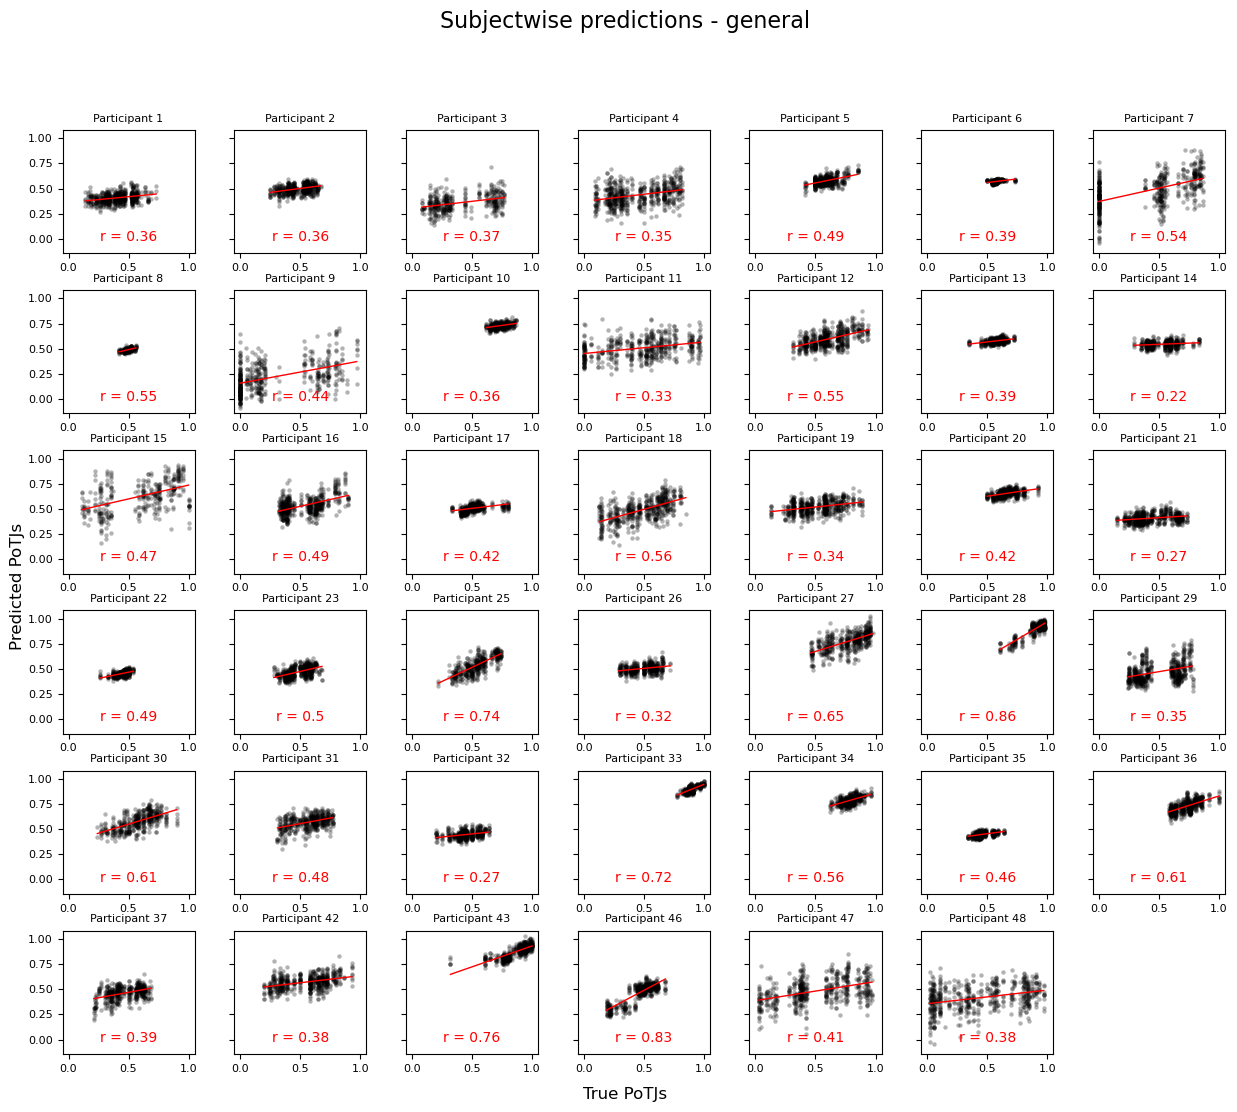

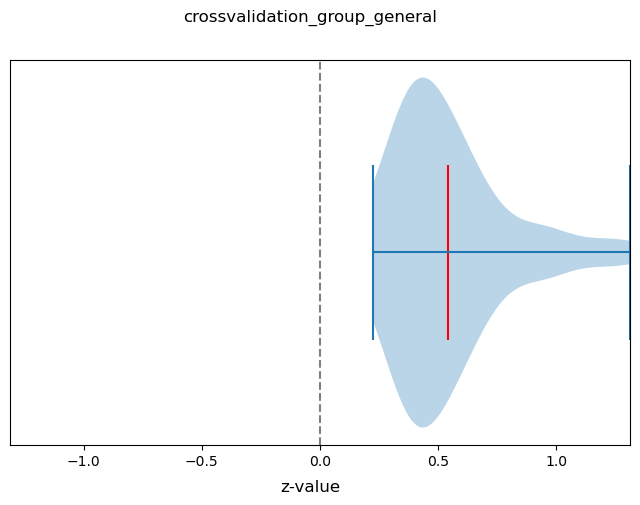

Averaged over subjects:
t(40) = 14.444, p < 0.001 ***


In [55]:
if perform_new_cross_validation:
    # Perform crossvalidation for each subject
    general_subjectwise_corrs = crossval_general(subjects, compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results)
    # load stored crossvalidation results for the whole group
else:
    with open(path_study_data / 'group_level' / 'prediction_test_results.pkl', 'rb') as f:
                general_subjectwise_corrs = pickle.load(f)

# Determine and print number of missing correlations (nans) per subject
general_missing_corrs = [np.isnan(subject) for subject in general_subjectwise_corrs]

print("")
print(f"Average correlation over group: {round(np.array(general_subjectwise_corrs).mean(axis=0), 3)}, SD = {round(np.array(general_subjectwise_corrs).std(axis=0), 3)}")
print(f"Missing correlations total: {sum(general_missing_corrs)}")
if sum(general_missing_corrs) > 0:
    print(f"Correlations missing for subjects: {[subjects[corr_nr] for corr_nr, corr in enumerate(general_missing_corrs) if corr]}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    general_subjectwise_corrs = [missing_correlation_entry if np.isnan(corr) else corr for corr in general_subjectwise_corrs]

# Plot predicted vs. true PoTJs for each participant
if show_subjectwise_prediction_plots or save_subjectwise_prediction_plots:
    # plot with z values
    # plot_subjectwise_predictions(subjects, general_subjectwise_corrs, data_file = "prediction_test_results.pkl",
    #                              show_plots = show_subjectwise_prediction_plots, save_plots = save_subjectwise_prediction_plots,
    #                              zvalues = True)
    
    # plot back transformed values
    plot_subjectwise_predictions(subjects, general_subjectwise_corrs, data_file = "prediction_test_results.pkl",
                                 show_plots = show_subjectwise_prediction_plots, save_plots = save_subjectwise_prediction_plots,
                                 zvalues = False)

# fishers r-to-z transform
general_subjectwise_zs = np.arctanh(general_subjectwise_corrs)

# perform t-test over all subjects (averaged over sets)
general_groupwise_result = sc.stats.ttest_1samp(general_subjectwise_zs, popmean = 0)

print("")
print("")
# plot average histogram
if show_average_prediction_plots or save_average_prediction_plots:
    plot_average_results(general_subjectwise_zs,
                        type = "violin", title = "crossvalidation_group_general", show_plots = show_average_prediction_plots, save_plots = save_average_prediction_plots,
                        figsize = (8, 5))

print("Averaged over subjects:")
print(stats_to_str(general_groupwise_result))


In [54]:
np.array(general_subjectwise_corrs).std(axis=0)



0.15192009268203108

Average z-tranformed correlation coefficients of the group differ significantly from zero. This means that the classifer prediction accuracy significantly exceeded the guessing rate. 

####  2.1.2 Permutation test

To ensure that classifiers did not pick up on data other then the snapshots features und thus the prediction accuracy was inflated by some kind of inadvertend or unexpected pattern, we performed a permutation test. The general approach resembled the five-fold cross-validation in 2.1.1, only here we assessed the classifier accuracies for data were the association between snapshot features and PoTJs were randomly shuffled. The permutation test was split in two steps:

1. For each subject, permute data 1000 times (randomly shuffle mapping between snapshot features and PotJs) perform five-fold cross-validation for each permutation run to assess classifier performance for randomly shuffled data.

2. In a second step we compared the prediction for correctly mapped data to the predictions for the permuted data (2.1.2)

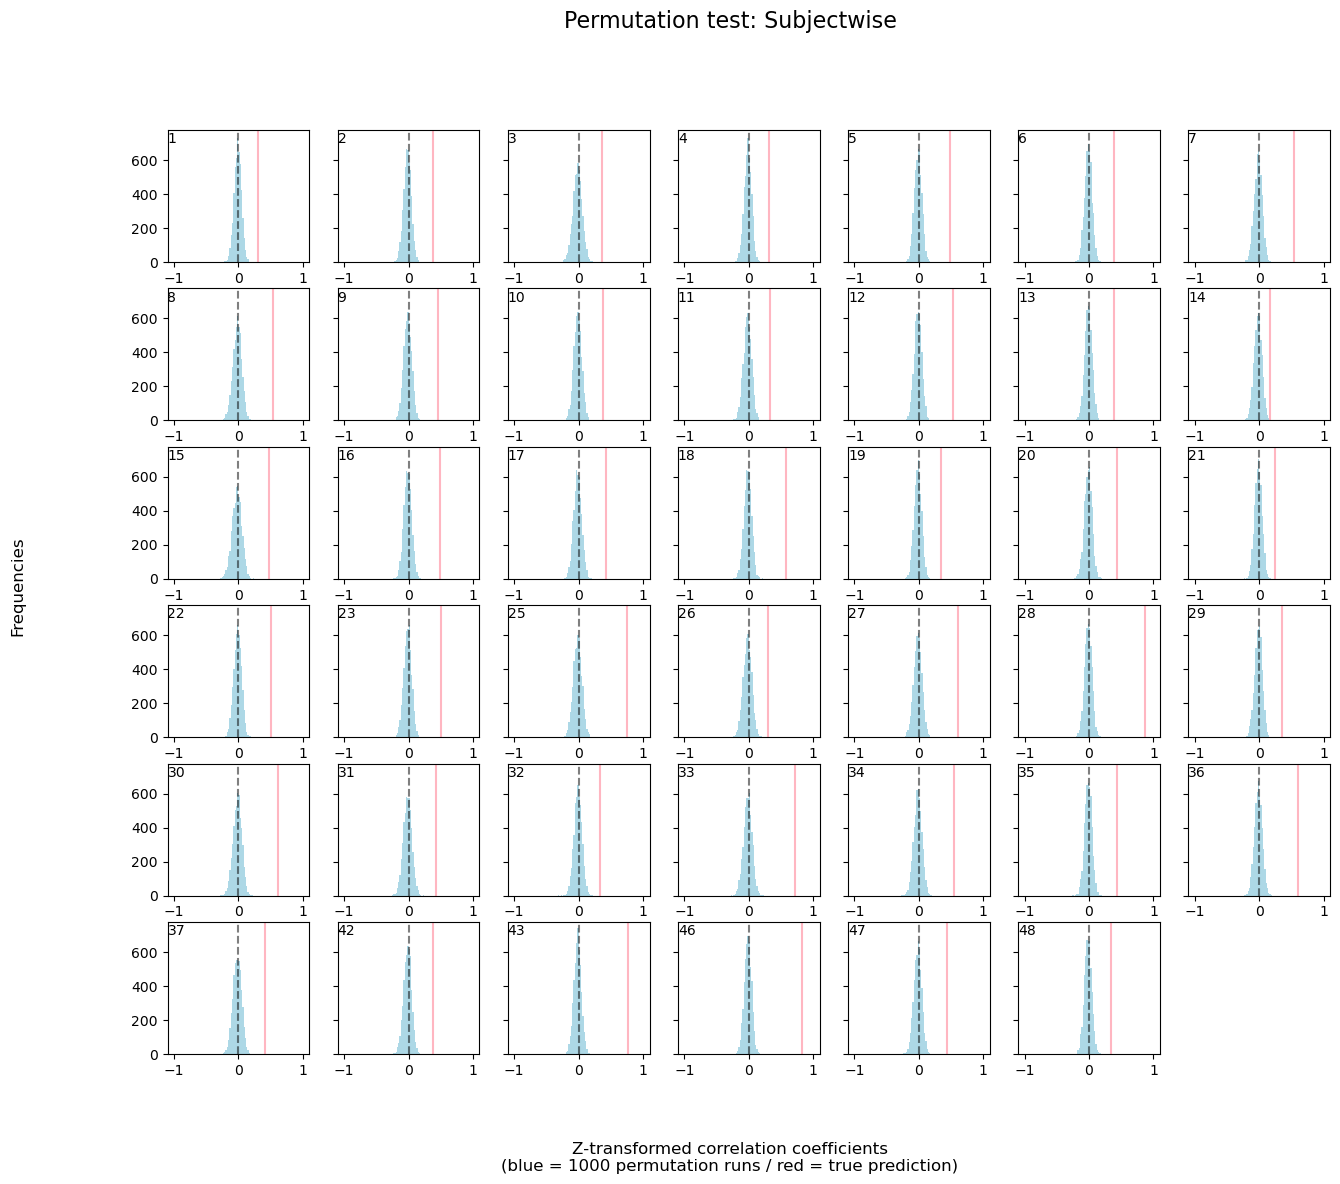

C:\Users\jordingma\AppData\Local\Temp\ipykernel_21964\111052554.py:78: UserWarning: FixedFormatter should only be used together with FixedLocator
  secax_y.set_yticklabels(labels_new)


(41,)


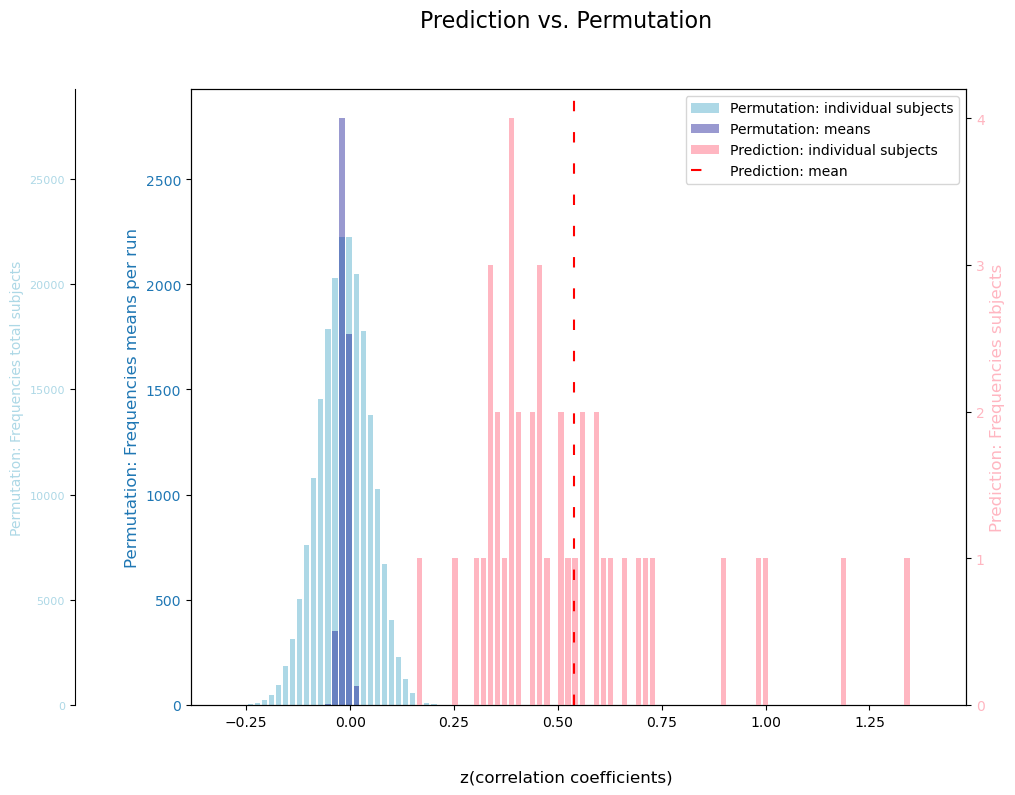

Testing for normal distribtution of permutation results: p = 7.295477403908425e-18

Assuming a normal distribution for permutation test results (m = -0.014135899180822118, sd = 0.06187496621361823),
the probability that the average z-transformed correlation coefficient (m = 0.5396057188260008) is part of this distribution is p < 0.001


c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [29]:
# perform permutation
group_permutation_results = permutation_test(subjects, permutation_runs, perform_new_permutation = perform_new_permutation, save_permutation_results = save_permutation_results)

# plot real predictions against permutations
#plot_prediction_and_permutation(show_plots = show_predictionvspermutation_plots, save_plots = show_predictionvspermutation_plots)

plot_prediction_and_permutation_subjectwise(subjects, show_plots = show_predictionvspermutation_plots, save_plots = save_predictionvspermutation_plots)


plot_prediction_and_permutation_group(subjects, show_plots = show_predictionvspermutation_plots, save_plots = save_predictionvspermutation_plots, figsize = (10, 8))



# testing whether permutation results follow a normal distribution 
permutation_normality_test = sc.stats.shapiro(group_permutation_results)
print(f"Testing for normal distribtution of permutation results: p = {permutation_normality_test[1]}")
print("")

# Use comulative density function to calculate the probability that the mean correlation coefficient is part of the distribution of permutation test results

set_warnings("ignore")
p = 1 - sc.stats.norm.cdf(np.mean(general_subjectwise_zs), np.mean(group_permutation_results), np.std(group_permutation_results))
set_warnings("default")


if p < 0.001:
    pvalue_text = "p < 0.001"
else:
    pvalue_text = f"p = {np.round(p, 3)}"

print(f"Assuming a normal distribution for permutation test results (m = {np.mean(group_permutation_results)}, sd = {np.std(group_permutation_results)}),")
print(f"the probability that the average z-transformed correlation coefficient (m = {np.mean(general_subjectwise_zs)}) is part of this distribution is {pvalue_text}")

Results: Histograms of correlation coefficients from 1000 runs of permutated data (blue) and from classifier predictions for correctly maped data (red) separate for each subject (top figure)<br> and averaged over all subjects (bottom figure). Classifier results for permuted data show prediction accuracys close to guessing rate for each subject. Accuracies for "real" predictions with a correct mapping between snapshot feauteres and PoTJs show a clear increase compared to permutation results.

---
---

## 2.2 Generalisation tests

Next, we tested whether classifiers would be able to generalize from feature-PoTJs associations from a specific situation A, i.e. a specific condition level, to feature-PoTJs associations from situation B, i.e.  a different condition level.

To this end, we first always tested in a five-fold cross-validation whether classifiers were able to predict PoTJs within the specific situation A. Therefore, for each subject and for each each specific condition level (e.g. each level of velocity) all snapshots from this condition level were split equally into five folds. Folds were then combined into five different training and test sets so that each possible combination of four folds was used once as training-set with the remaining fold constituting the corresponding test-set. Within each participant and for each condition level, the classifiers predictions from all five training-test sets were then correlated against the respective true PoTJs.
Thus, per participant and per condition level one correlation coefficient resulted. For each condition level, correlation coefficients from all subjects were then z-transformed and tested separately against zero with a t-test. Afterwards, all correlation coefficients from the whole group and for all different condition levels were then combined and tested against zero in a t-test.

In order to test the generalizability between situations A and B, we then trained a classifier on all snapshots from situation A and tested the accuracy of the classifiers’ predictions for situation B. Thus per subject, for each possible combination of two condition levels we trained a classifier on one and tested it on the other. We then computed the correlations separately, resulting in one correlation coefficient per condition level combination and subject. For each condition level combination z-transformed correlation coefficients from all subjects were then combined and tested against zero in a t-test. Afterwards, all correlation coefficients from the whole group and for all different condition level combinations were then combined and tested against zero in a t-test.

Five-fold cross-validation and generalization tests were conducted with generative functions which are defined first.
Afterwards, the analyses are presented for the generalizations between:
- specific velocity levels (2.2.1), including a five-fold cross-validation (2.2.1.1) and the generalisation test (2.2.1.2) 
- specific density levels (2.2.2), including a five-fold cross-validation (2.2.2.1) and the generalisation test (2.2.2.2)
- specific velocity & density level combinations (2.2.3), including a five-fold cross-validation (2.2.3.1) and the generalisation test (2.2.3.2)

---
### 2.2.1 Generalisation velocity conditions

#### 2.2.1.1 Crossvalidation within velocity conditions


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 2



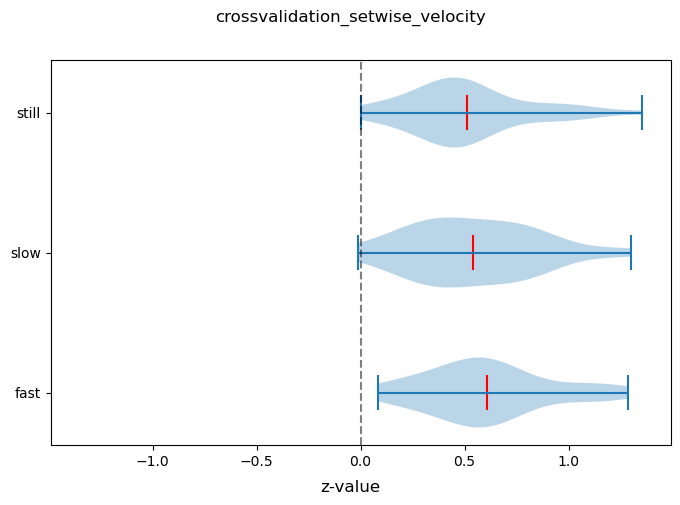


Setwise results:
	                    still: 	t(40) = 11.186, p < 0.001 ***
	                     slow: 	t(40) = 11.454, p < 0.001 ***
	                     fast: 	t(40) = 13.091, p < 0.001 ***
Alpha error corrected p-value threshold: * = 0.016666666666666666 / ** = 0.0033333333333333335 / *** = 0.0003333333333333333




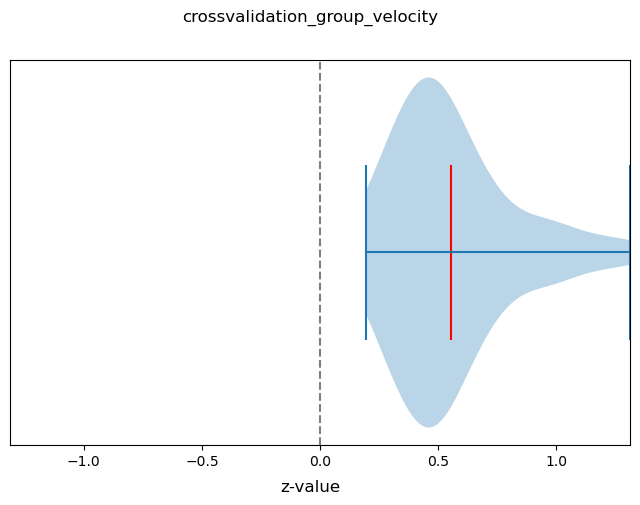

Averaged over subjects:
t(40) = 14.144, p < 0.001 ***


In [30]:
# Define sets (condition levels or combination of condition levels) within which classifiers should be crossvalidated
sets = pd.DataFrame(data = {"condition": [["velocity"], ["velocity"], ["velocity"]],
                            "levels": [[[velocity_level_label[0]]], [[velocity_level_label[1]]], [[velocity_level_label[2]]]]})

if perform_new_cross_validation:
    # Perform crossvalidation for each subject and each set
    velcrossval_setwise_corrs = crossval_conditionspecific(subjects, sets = sets,
                                                           compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                                           title = "velocity")
    # load stored crossvalidation results for the whole group
else:
    with open(path_data_grouplevel / f'crossvalidation_velocity_group_correlations.pkl', 'rb') as f:
                velcrossval_setwise_corrs = pickle.load(f)
    
    
# Determine and print number of missing correlations (nans) per subject
vel_crossval_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in velcrossval_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {vel_crossval_missing_corrs}")
print(f"Missing correlations total: {sum(vel_crossval_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    velcrossval_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in velcrossval_setwise_corrs]

# fishers r-to-z transform
velcrossval_setwise_zs = np.arctanh(velcrossval_setwise_corrs)

# perform t-test for each set
velcrossval_setwise_results = setwise_ttests(velcrossval_setwise_zs)

# plot setwise histograms
if show_validation_setwise_plots or save_validation_setwise_plots:
    plot_setwise_results(velcrossval_setwise_zs,
                        trainingset_labels = create_setlabels(sets),
                        type = "violin", title = "crossvalidation_setwise_velocity", show_plots = show_validation_setwise_plots, save_plots = save_validation_setwise_plots,
                        wspace = 0.1, hspace = 0.1, figsize = (8,5))

print("")
print("Setwise results:")

nr_of_comparissons = len(velcrossval_setwise_results)
for set_nr, set in enumerate(velcrossval_setwise_results):
    print(f"\t{create_setlabels(sets)[set_nr]:>25}: \t{stats_to_str(set, nr_of_comparissons = nr_of_comparissons)}")

nr_of_comparissons = len(velcrossval_setwise_results)   
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")
    

# average per participant
velcrossval_subjectwise_zs = velcrossval_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
velcrossval_groupwise_result = sc.stats.ttest_1samp(velcrossval_subjectwise_zs, popmean = 0)

print("")
print("")
# plot average histogram
if show_validation_average_plots or save_validation_average_plots:
    plot_average_results(velcrossval_subjectwise_zs,
                        type = "violin", title = "crossvalidation_group_velocity", show_plots = show_validation_average_plots, save_plots = save_validation_average_plots,
                        figsize = (8, 5))

print("Averaged over subjects:")
print(stats_to_str(velcrossval_groupwise_result))    

Cross-validation results for individual velocity condition levels (top figure) and summarized over all velocity condition levels (bottom figure)<br>show that classifiers were able to predict PoTJs within velocity conditions

#### 2.2.1.2 Generalization between velocity conditions


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 4, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 6



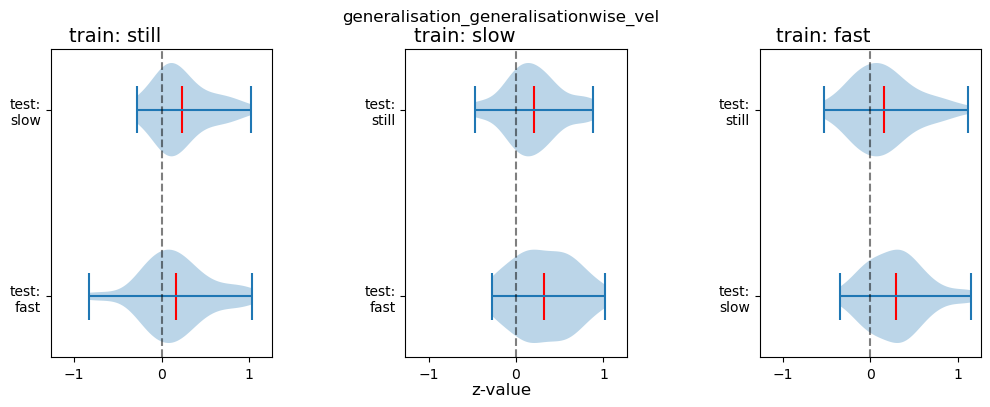

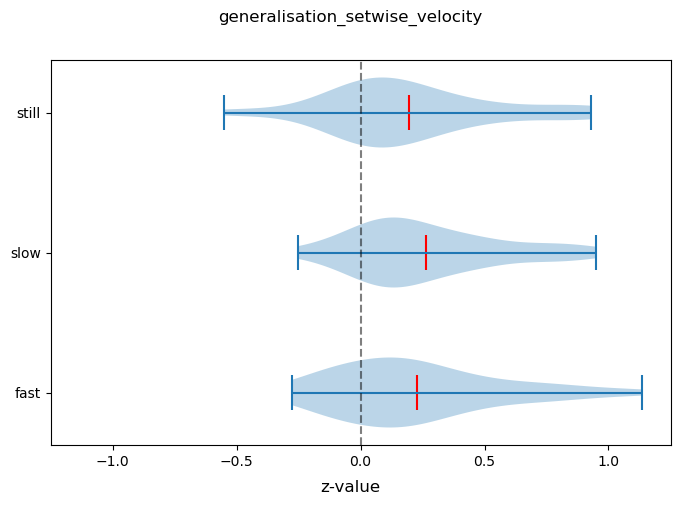

	set 1: 	t(40) = 4.609, p < 0.001 ***
	set 2: 	t(40) = 2.658, p = 0.011 (n.s.)
	set 3: 	t(40) = 4.06, p < 0.001 **
	set 4: 	t(40) = 5.992, p < 0.001 ***
	set 5: 	t(40) = 2.761, p = 0.009 (n.s.)
	set 6: 	t(40) = 5.608, p < 0.001 ***
Alpha error corrected p-value threshold: * = 0.008333333333333333 / ** = 0.0016666666666666668 / *** = 0.00016666666666666666


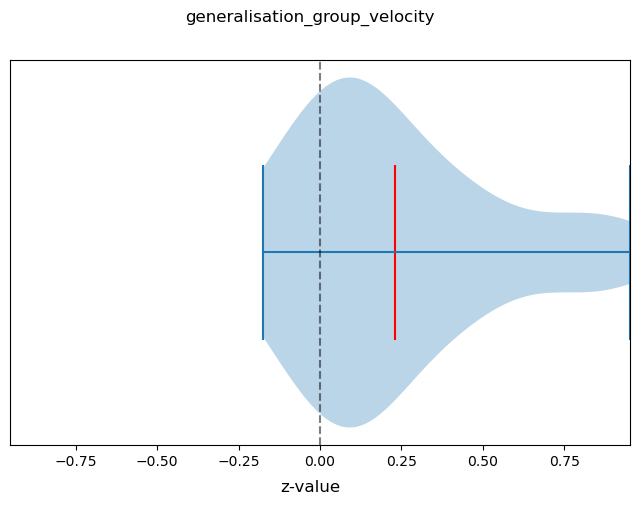


Averaged over subjects:
t(40) = 4.826, p < 0.001 ***


In [31]:
training_sets = pd.DataFrame(data = {"condition": [["velocity"], ["velocity"], ["velocity"], ["velocity"], ["velocity"], ["velocity"]],
                                     "levels": [[[velocity_level_label[0]]], [[velocity_level_label[0]]], [[velocity_level_label[1]]], [[velocity_level_label[1]]], [[velocity_level_label[2]]], [[velocity_level_label[2]]]]})

test_sets = pd.DataFrame(data = {"condition": [["velocity"], ["velocity"], ["velocity"], ["velocity"], ["velocity"], ["velocity"]],
                                 "levels": [[[velocity_level_label[1]]], [[velocity_level_label[2]]], [[velocity_level_label[0]]], [[velocity_level_label[2]]], [[velocity_level_label[0]]], [[velocity_level_label[1]]]]})

# Perform generalisation for each subject and each set
if perform_new_generalisation:
    velgen_setwise_corrs = generalisation_test(subjects, training_sets = training_sets, test_sets = test_sets,
                                               compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                               title = "velocity")
# load stored generalisation results for the whole group
else:
    with open(path_data_grouplevel / f'generalisation_velocity_group_correlations.pkl', 'rb') as f:
        velgen_setwise_corrs = pickle.load(f)


# Determine and print number of missing correlations (nans) per subject
vel_gen_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in velgen_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {vel_gen_missing_corrs}")
print(f"Missing correlations total: {sum(vel_gen_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    velgen_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in velgen_setwise_corrs]

# fishers r-to-z transform
velgen_setwise_zs = np.arctanh(velgen_setwise_corrs)

# perform t-test for each set
velgen_setwise_results = setwise_ttests(velgen_setwise_zs)

# plots accuracies for each generalisation from each training set to each test set
if show_generalisation_pairwise_plots or save_generalisation_pairwise_plots:      
        
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    velgen_trainingsetwise = []
    for trainset in range(0,3):
        # turn into list of trainingsets including list of testsets including list of subjects
        testset_data = []
        for testset in range(0,2):
            testset_data.append([subject[(trainset * 2) + testset] for subject in velgen_setwise_zs])
        velgen_trainingsetwise.append(testset_data) 
        testsetlabels_setwise.extend([testset_labels[trainset*2:(trainset+1)*2]])
        
    # create training set labels
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]
    
    subplot_coords = {'rows': [0,1,2],
                      'cols': [0,0,0]}

    plot_setwise_results(velgen_trainingsetwise,
                         trainingset_labels = trainingset_labels, testset_labels = testsetlabels_setwise,
                         type = "violin", separate_subplots = True, subplot_coords = subplot_coords, title = "generalisation_generalisationwise_vel",
                         show_plots = show_generalisation_pairwise_plots, save_plots = save_generalisation_pairwise_plots,
                         wspace = 0.6, hspace = 0.2, figsize = (12,4))
       
    
# plots average accuracies for each training set
if show_generalisation_setwise_plots or save_generalisation_setwise_plots:
    
    # average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    unique_labels = labels[list(np.sort(idx))]
    
    set_averages = []
    for subject_zs in velgen_setwise_zs:  
        subject_averages = []
        for label in unique_labels:
            idx = np.where(np.array(labels) == label)
            subject_averages.append(np.mean(subject_zs[idx]))
        set_averages.append(subject_averages)
    
    plot_setwise_results(np.array(set_averages),
                     trainingset_labels = list(unique_labels),
                     type = "violin", title = "generalisation_setwise_velocity", show_plots = show_generalisation_setwise_plots, save_plots = save_generalisation_setwise_plots,
                     wspace = 0.1, hspace = 0.1, figsize = (8,5))



nr_of_comparissons = len(velgen_setwise_results)   
# print setweise results
for set_nr, set in enumerate(velgen_setwise_results):
    print(f"\tset {set_nr+1:>}: \t{stats_to_str(set, nr_of_comparissons = len(velgen_setwise_results))}")
    
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")
    
    
# average per participant
velgen_subjectwise_zs = velgen_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
velgen_groupwise_result = sc.stats.ttest_1samp(velgen_subjectwise_zs, popmean = 0)

# plot average histogram
if show_generalisation_average_plots or save_generalisation_average_plots:
    plot_average_results(velgen_subjectwise_zs,
                        type = "violin", title = "generalisation_group_velocity", show_plots = show_generalisation_average_plots, save_plots = save_generalisation_average_plots,
                        figsize = (8, 5))  

print("")
print("Averaged over subjects:")
print(stats_to_str(velgen_groupwise_result))                   

#### 2.2.1.3 Plots velocity validation and generalisation

c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


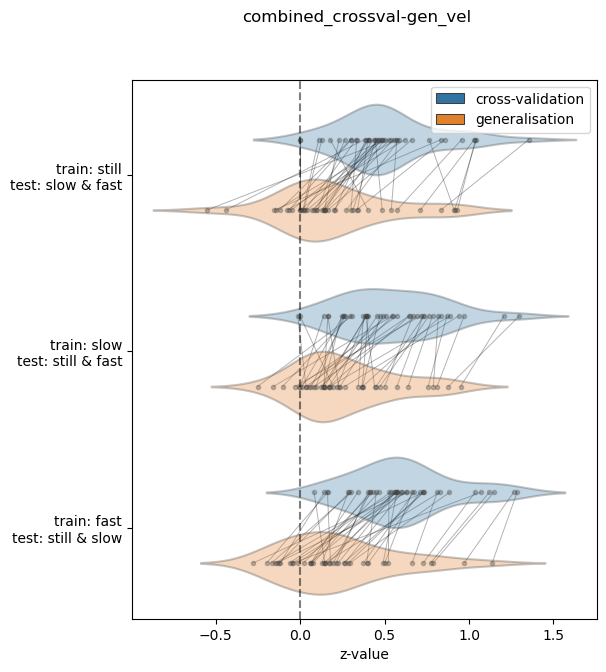

In [32]:
if show_validation_generalisation_plots or save_validation_generalisation_plots:      
        
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    velgen_trainingsetwise = []
    for trainset in range(0,3):
        # turn into list of trainingsets including list of testsets including list of subjects
        testset_data = []
        for testset in range(0,2):
            testset_data.append([subject[(trainset * 2) + testset] for subject in velgen_setwise_zs])
        velgen_trainingsetwise.append(testset_data) 
        testsetlabels_setwise.extend([testset_labels[trainset*2:(trainset+1)*2]])
        
    # create training set labels
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]


    # average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    unique_labels = labels[list(np.sort(idx))]
    
    set_averages = []
    for subject_zs in velgen_setwise_zs:  
        subject_averages = []
        for label in unique_labels:
            idx = np.where(np.array(labels) == label)
            subject_averages.append(np.mean(subject_zs[idx]))
        set_averages.append(subject_averages)
    

    plot_validation_and_generalisation(validation_setwise_zs = velcrossval_setwise_zs, generalisation_setwise_zs = set_averages,
                                       trainingset_labels = trainingset_labels,
                                       testset_labels = testsetlabels_setwise,
                                       connect_analyses = connect_analyses, connect_sets = connect_sets,
                                       title = "combined_crossval-gen_vel", show_plots = show_validation_generalisation_plots, save_plots = save_validation_generalisation_plots,
                                       figsize = (6, 7))


Results for generalisations between individual velocity condition levels (top figure) and summarized over combinations of individual velocity condition levels (bottom figure)<br>show that classifiers were able to generalize PoTJs irrespective of the velocity"

In [33]:
subject_zs.shape

(6,)

---
### 2.2.2 Generalisation density conditions

#### 2.2.2.1 Crossvalidation within density conditions


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 0



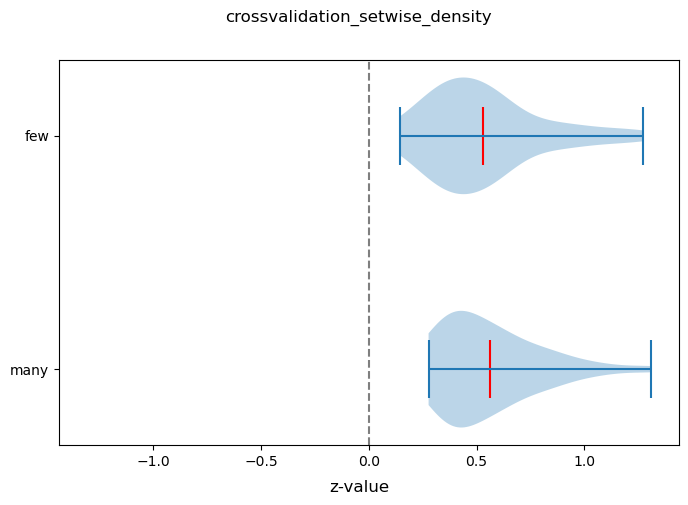

Alpha error corrected p-value threshold: * = 0.016666666666666666 / ** = 0.0033333333333333335 / *** = 0.0003333333333333333
Setwise results:
	                      few: 	t(40) = 13.082, p < 0.001 ***
	                     many: 	t(40) = 15.387, p < 0.001 ***
Alpha error corrected p-value threshold: 0.025




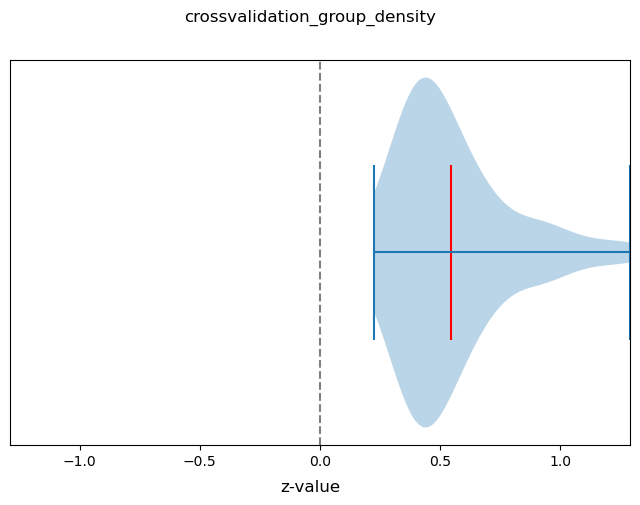

Averaged over subjects:
t(40) = 15.068, p < 0.001 ***


In [34]:
# Define sets (condition levels or combination of condition levels) within which classifiers should be crossvalidated
sets = pd.DataFrame(data = {"condition": [["density"], ["density"]],
                            "levels": [[[density_level_label[0]]], [[density_level_label[1]]]]})

if perform_new_cross_validation:
    # Perform crossvalidation for each subject and each set
    dencrossval_setwise_corrs = crossval_conditionspecific(subjects, sets = sets,
                                                           compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                                           title = "density")
else:
    with open(path_data_grouplevel / f'crossvalidation_density_group_correlations.pkl', 'rb') as f:
                dencrossval_setwise_corrs = pickle.load(f)

# Determine and print number of missing correlations (nans) per subject
den_crossval_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in dencrossval_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {den_crossval_missing_corrs}")
print(f"Missing correlations total: {sum(den_crossval_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    dencrossval_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in dencrossval_setwise_corrs]
    
# fishers r-to-z transform
dencrossval_setwise_zs = np.arctanh(dencrossval_setwise_corrs)

# perform t-test for each set
dencrossval_setwise_results = setwise_ttests(dencrossval_setwise_zs)

# plot setwise histograms
if show_validation_setwise_plots or save_validation_setwise_plots:
    plot_setwise_results(dencrossval_setwise_zs,
                        trainingset_labels = create_setlabels(sets),
                        type = "violin", title = "crossvalidation_setwise_density", show_plots = show_validation_setwise_plots, save_plots = save_validation_setwise_plots,
                        wspace = 0.1, hspace = 0.1, figsize = (8,5))




nr_of_comparissons = len(velcrossval_setwise_results)   
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")

print("Setwise results:")
for set_nr, set in enumerate(dencrossval_setwise_results):
    print(f"\t{create_setlabels(sets)[set_nr]:>25}: \t{stats_to_str(set, nr_of_comparissons = len(dencrossval_setwise_results))}")
    
print(f"Alpha error corrected p-value threshold: {0.05 / len(dencrossval_setwise_results)}")

# average per participant
dencrossval_subjectwise_zs = dencrossval_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
dencrossval_groupwise_result = sc.stats.ttest_1samp(dencrossval_subjectwise_zs, popmean = 0)


print("")
print("")
# plot average histogram
if show_validation_average_plots or save_validation_average_plots:
    plot_average_results(dencrossval_subjectwise_zs,
                        type = "violin", title = "crossvalidation_group_density", show_plots = show_validation_average_plots, save_plots = save_validation_average_plots,
                        figsize = (8, 5))

print("Averaged over subjects:")
print(stats_to_str(dencrossval_groupwise_result))            

Cross-validation results for individual density condition levels (top figure) and summarized over all density condition levels (bottom figure)<br>show that classifiers were able to predict PoTJs within density conditions"

#### 2.2.2.2 Generalization between density conditions


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 0



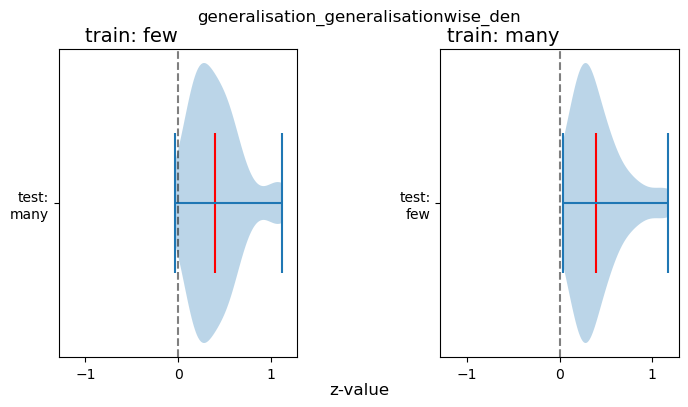

	set 1: 	t(40) = 9.444, p < 0.001 ***
	set 2: 	t(40) = 9.171, p < 0.001 ***
Alpha error corrected p-value threshold: * = 0.025 / ** = 0.005 / *** = 0.0005


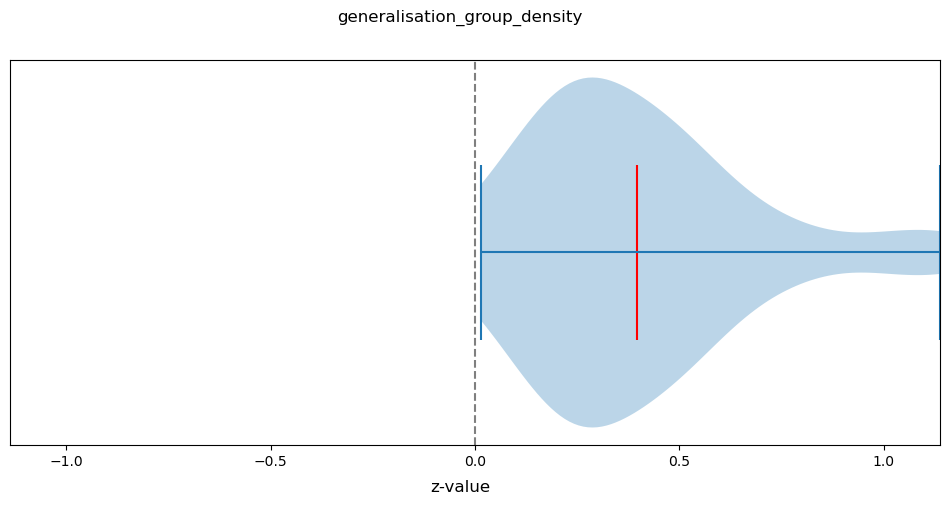


Averaged over subjects:
t(40) = 9.422, p < 0.001 ***


In [35]:

training_sets = pd.DataFrame(data = {"condition": [["density"], ["density"]],
                                               "levels": [[[density_level_label[0]]], [[density_level_label[1]]]]})

test_sets = pd.DataFrame(data = {"condition": [["density"], ["density"]],
                                               "levels": [[[density_level_label[1]]], [[density_level_label[0]]]]})

# Perform generalisation for each subject and each set
if perform_new_generalisation:
    dengen_setwise_corrs = generalisation_test(subjects, training_sets = training_sets, test_sets = test_sets,
                                               compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                               title = "density")
# load stored generalisation results for the whole group
else:
    with open(path_data_grouplevel / f'generalisation_density_group_correlations.pkl', 'rb') as f:
        dengen_setwise_corrs = pickle.load(f)
    
# Determine and print number of missing correlations (nans) per subject
den_gen_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in dengen_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {den_gen_missing_corrs}")
print(f"Missing correlations total: {sum(den_gen_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    dengen_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in dengen_setwise_corrs]

# fishers r-to-z transform
dengen_setwise_zs = np.arctanh(dengen_setwise_corrs)

# perform t-test for each set
dengen_setwise_results = setwise_ttests(dengen_setwise_zs)

# # plot histograms for each generalisation between two individual sets 
if show_generalisation_setwise_plots or save_generalisation_setwise_plots:
   
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    dengen_trainingsetwise = []
    
    for trainset in range(0,2):
        # create list of trainingsets including list of testsets including list of subjects
        dengen_trainingsetwise.append([[subject[trainset] for subject in dengen_setwise_zs]]) 
        testsetlabels_setwise.append([testset_labels[trainset]])
       
    #average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]
    
    subplot_coords = {'rows': [0,1],
                      'cols': [0,0]}
    
    plot_setwise_results(dengen_trainingsetwise,
                         trainingset_labels = trainingset_labels, testset_labels = testsetlabels_setwise,
                         type = "violin", separate_subplots = True, subplot_coords = subplot_coords, title = "generalisation_generalisationwise_den", show_plots = show_generalisation_setwise_plots, save_plots = save_generalisation_setwise_plots,
                         wspace = 0.6, hspace = 0.2, figsize = (8,4))




nr_of_comparissons = len(dengen_setwise_results)   
# print setweise results
for set_nr, set in enumerate(dengen_setwise_results):
    print(f"\tset {set_nr+1:>}: \t{stats_to_str(set, nr_of_comparissons = nr_of_comparissons)}")
    
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")


# average per participant
dengen_subjectwise_zs = dengen_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
dengen_groupwise_result = sc.stats.ttest_1samp(dengen_subjectwise_zs, popmean = 0)

# plot average histogram
if show_generalisation_average_plots or save_generalisation_average_plots:
    plot_average_results(dengen_subjectwise_zs,
                        type = "violin", title = "generalisation_group_density", show_plots = show_generalisation_average_plots, save_plots = save_generalisation_average_plots,
                        figsize = (12, 5))  

print("")
print("Averaged over subjects:")
print(stats_to_str(dengen_groupwise_result))            

#### 2.2.2.3 Plots density validation and generalisation

c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


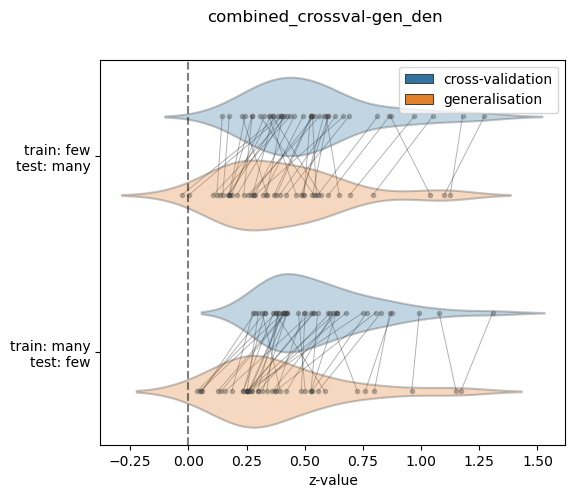

In [36]:
if show_validation_generalisation_plots or save_validation_generalisation_plots:
    
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    dengen_trainingsetwise = []
    
    for trainset in range(0,2):
        # create list of trainingsets including list of testsets including list of subjects
        dengen_trainingsetwise.append([[subject[trainset] for subject in dengen_setwise_zs]]) 
        testsetlabels_setwise.append([testset_labels[trainset]])
       
    #average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]
    
    plot_validation_and_generalisation(validation_setwise_zs = dencrossval_setwise_zs, generalisation_setwise_zs = dengen_setwise_zs,
                                       trainingset_labels = trainingset_labels,
                                       testset_labels = testsetlabels_setwise,
                                       connect_analyses = connect_analyses, connect_sets = connect_sets,
                                       title = "combined_crossval-gen_den", show_plots = show_validation_generalisation_plots, save_plots = save_validation_generalisation_plots,
                                       figsize = (6, 5))

Results for generalisations between individual density condition levels (top figure) and summarized over combinations of individual density condition levels (bottom figure)<br> show that classifiers were able to generalize PoTJs irrespective of the density

---
### 2.2.3 Generalization specific condition combinations

#### 2.2.3.1 Crossvalidation within specific density/velocity condition combinations


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 4



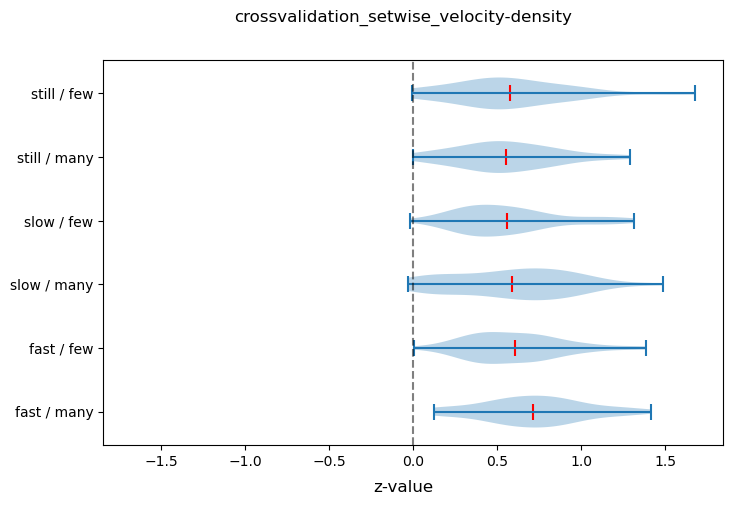

Setwise results:
	              still / few: 	t(40) = 10.141, p < 0.001 ***
	             still / many: 	t(40) = 11.772, p < 0.001 ***
	               slow / few: 	t(40) = 11.785, p < 0.001 ***
	              slow / many: 	t(40) = 10.528, p < 0.001 ***
	               fast / few: 	t(40) = 13.539, p < 0.001 ***
	              fast / many: 	t(40) = 14.846, p < 0.001 ***
Alpha error corrected p-value threshold: * = 0.008333333333333333 / ** = 0.0016666666666666668 / *** = 0.00016666666666666666




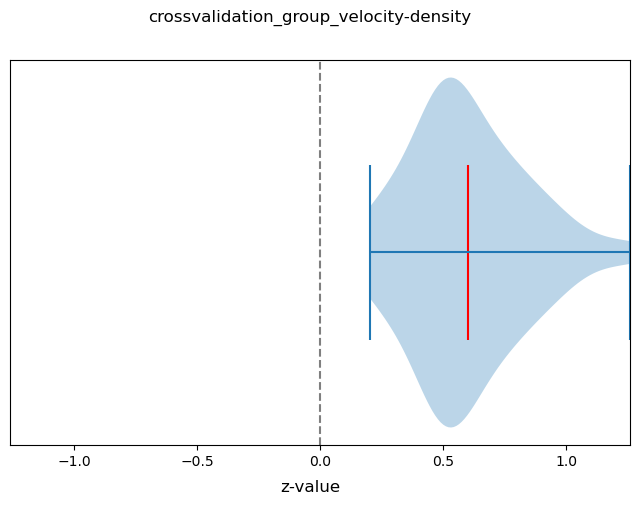

Averaged over subjects:
t(40) = 16.606, p < 0.001 ***


In [37]:
# Define sets (condition levels or combination of condition levels) within which classifiers should be crossvalidated
sets = pd.DataFrame(data = {"condition": [["velocity", "density"], ["velocity", "density"], ["velocity", "density"], ["velocity", "density"], ["velocity", "density"], ["velocity", "density"]],
                                                      "levels": [[[velocity_level_label[0]], [density_level_label[0]]], [[velocity_level_label[0]], [density_level_label[1]]], [[velocity_level_label[1]], [density_level_label[0]]], [[velocity_level_label[1]], [density_level_label[1]]], [[velocity_level_label[2]], [density_level_label[0]]], [[velocity_level_label[2]], [density_level_label[1]]]]})

# Perform crossvalidation for each subject and each set
if perform_new_cross_validation:
    veldencrossval_setwise_corrs = crossval_conditionspecific(subjects, sets = sets,
                                                              compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                                              title = "velocity-density")
else:
    with open(path_data_grouplevel / f'crossvalidation_velocity-density_group_correlations.pkl', 'rb') as f:
                veldencrossval_setwise_corrs = pickle.load(f)

# Determine and print number of missing correlations (nans) per subject
velden_crossval_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in veldencrossval_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {velden_crossval_missing_corrs}")
print(f"Missing correlations total: {sum(velden_crossval_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    veldencrossval_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in veldencrossval_setwise_corrs]

# fishers r-to-z transform
veldencrossval_setwise_zs = np.arctanh(veldencrossval_setwise_corrs)

# perform t-test for each set
veldencrossval_setwise_results = setwise_ttests(veldencrossval_setwise_zs)

# plot setwise histograms
if show_validation_setwise_plots or save_validation_setwise_plots:
    plot_setwise_results(veldencrossval_setwise_zs,
                        trainingset_labels = create_setlabels(sets),
                        type = "violin", title = "crossvalidation_setwise_velocity-density", show_plots = show_validation_setwise_plots, save_plots = save_validation_setwise_plots,
                        wspace = 0.1, hspace = 0.1, figsize = (8,5))



nr_of_comparissons = len(veldencrossval_setwise_results)

print("Setwise results:")
for set_nr, set in enumerate(veldencrossval_setwise_results):
    print(f"\t{create_setlabels(sets)[set_nr]:>25}: \t{stats_to_str(set, nr_of_comparissons = nr_of_comparissons)}")
    
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")
    

    
# average per participant
veldencrossval_subjectwise_zs = veldencrossval_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
veldencrossval_groupwise_result = sc.stats.ttest_1samp(veldencrossval_subjectwise_zs, popmean = 0)


print("")
print("")
# plot average histogram
if show_validation_average_plots or save_validation_average_plots:
    plot_average_results(veldencrossval_subjectwise_zs,
                        type = "violin", title = "crossvalidation_group_velocity-density", show_plots = show_validation_average_plots, save_plots = save_validation_average_plots,
                        figsize = (8, 5))

print("Averaged over subjects:")
print(stats_to_str(veldencrossval_groupwise_result))          

Cross-validation results for individual velocity/density level combination (top figure) and summarized over all combinations (bottom figure)<br>show that classifiers were able to predict PoTJs within specific condition combinations

#### 2.2.3.2 Generalisation between specific density/velocity condition combinations


Missing correlations per subject: [0, 0, 0, 0, 0, 0, 18, 0, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Missing correlations total: 32



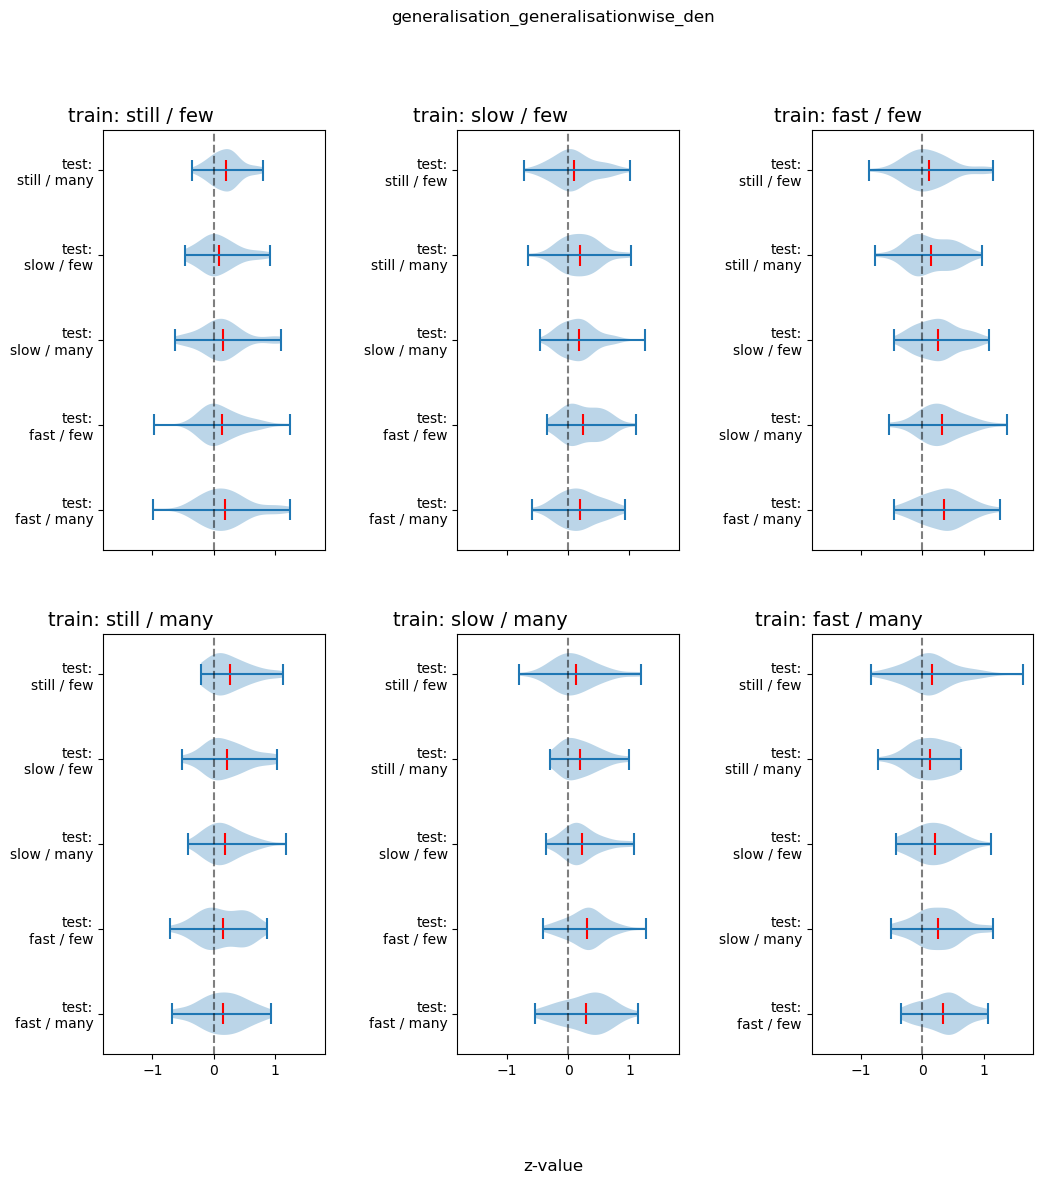

['still / few' 'still / many' 'slow / few' 'slow / many' 'fast / few'
 'fast / many']
[['still / many', 'slow / few', 'slow / many', 'fast / few', 'fast / many'], ['still / few', 'slow / few', 'slow / many', 'fast / few', 'fast / many'], ['still / few', 'still / many', 'slow / many', 'fast / few', 'fast / many'], ['still / few', 'still / many', 'slow / few', 'fast / few', 'fast / many'], ['still / few', 'still / many', 'slow / few', 'slow / many', 'fast / many'], ['still / few', 'still / many', 'slow / few', 'slow / many', 'fast / few']]


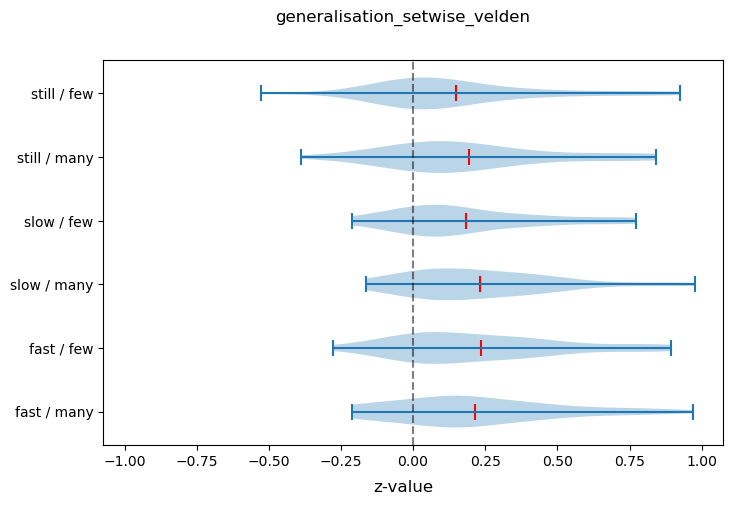

	set 1: 	t(40) = 4.906, p < 0.001 ***
	set 2: 	t(40) = 1.754, p = 0.087 (n.s.)
	set 3: 	t(40) = 2.287, p = 0.028 (n.s.)
	set 4: 	t(40) = 2.177, p = 0.035 (n.s.)
	set 5: 	t(40) = 2.713, p = 0.01 (n.s.)
	set 6: 	t(40) = 4.821, p < 0.001 ***
	set 7: 	t(40) = 3.713, p < 0.001 *
	set 8: 	t(40) = 3.64, p < 0.001 *
	set 9: 	t(40) = 2.364, p = 0.023 (n.s.)
	set 10: 	t(40) = 2.464, p = 0.018 (n.s.)
	set 11: 	t(40) = 1.83, p = 0.075 (n.s.)
	set 12: 	t(40) = 3.688, p < 0.001 *
	set 13: 	t(40) = 3.557, p < 0.001 *
	set 14: 	t(40) = 4.82, p < 0.001 ***
	set 15: 	t(40) = 3.613, p < 0.001 *
	set 16: 	t(40) = 2.063, p = 0.046 (n.s.)
	set 17: 	t(40) = 4.062, p < 0.001 **
	set 18: 	t(40) = 4.51, p < 0.001 **
	set 19: 	t(40) = 5.827, p < 0.001 ***
	set 20: 	t(40) = 4.8, p < 0.001 ***
	set 21: 	t(40) = 1.765, p = 0.085 (n.s.)
	set 22: 	t(40) = 2.369, p = 0.023 (n.s.)
	set 23: 	t(40) = 4.651, p < 0.001 **
	set 24: 	t(40) = 5.244, p < 0.001 ***
	set 25: 	t(40) = 5.806, p < 0.001 ***
	set 26: 	t(40) = 2.03, 

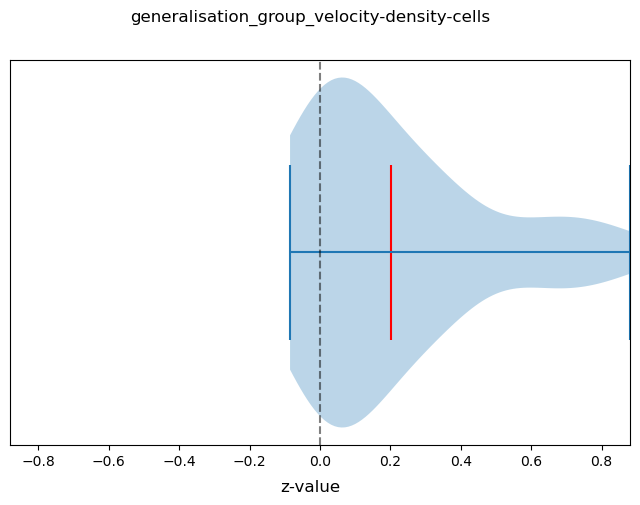


Averaged over subjects:
t(40) = 4.997, p < 0.001 ***


In [38]:
velocity_levels = [[velocity_level_label[0]], [velocity_level_label[1]], [velocity_level_label[2]]]
density_levels = [[density_level_label[0]], [density_level_label[1]]]

# table of unique condition combinations (cells)
condition_combinations = pd.DataFrame(itertools.product(velocity_levels, density_levels), columns = ["velocity", "density"])

# bind together both variables
condition_combinations_list = [[row["velocity"], row["density"]] for _, row in condition_combinations.iterrows()]

# find all permutations
all_permutations = list(itertools.permutations(condition_combinations_list, 2))

# initiate training and test set
training_sets, test_sets= pd.DataFrame(columns=('condition', 'levels')), pd.DataFrame(columns=('condition', 'levels'))

# create training and test sets using all possible cell combinations
for comb_nr, comb in enumerate(all_permutations):   
    training_sets.loc[comb_nr] = [["velocity", "density"], [comb[0][0], comb[0][1]]]
    test_sets.loc[comb_nr] = [["velocity", "density"], [comb[1][0], comb[1][1]]]

# Perform generalisation for each subject and each set
if perform_new_generalisation:
    veldengen_setwise_corrs = generalisation_test(subjects, training_sets = training_sets, test_sets = test_sets,
                                                  compute_new_subject_results = compute_new_subject_results, save_subject_results = save_subject_results, save_group_results = save_group_results,
                                                  title = "velocity-density")
# load stored generalisation results for the whole group
else:
    with open(path_data_grouplevel / f'generalisation_velocity-density_group_correlations.pkl', 'rb') as f:
        veldengen_setwise_corrs = pickle.load(f)

# Determine and print number of missing correlations (nans) per subject
velden_gen_missing_corrs = [sum(x) for x in [np.isnan(subject) for subject in veldengen_setwise_corrs]]

print("")
print(f"Missing correlations per subject: {velden_gen_missing_corrs}")
print(f"Missing correlations total: {sum(velden_gen_missing_corrs)}")
print("")

# replace missing correlations
if not np.isnan(missing_correlation_entry):
    veldengen_setwise_corrs = [[missing_correlation_entry if np.isnan(corr) else corr for corr in subject ] for subject in veldengen_setwise_corrs]

# fishers r-to-z transform
veldengen_setwise_zs = np.arctanh(veldengen_setwise_corrs)

# perform t-test for each set
veldengen_setwise_results = setwise_ttests(veldengen_setwise_zs)


# # plot each generalisation between two individual sets
if show_generalisation_pairwise_plots or save_generalisation_pairwise_plots:  
        
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    dengen_trainingsetwise = []
    for trainset in range(0,6):
        # turn into list of trainingsets including list of testsets including list of subjects
        testset_data = []
        for testset in range(0,5):
            testset_data.append([subject[(trainset * 5) + testset] for subject in veldengen_setwise_zs])
        dengen_trainingsetwise.append(testset_data) 
        testsetlabels_setwise.extend([testset_labels[trainset*5:(trainset+1)*5]])
        
    # create training set labels
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]
    
    subplot_coords = {'rows': [0,0,1,1,2,2],
                      'cols': [0,1,0,1,0,1]}

    plot_setwise_results(dengen_trainingsetwise,
                         trainingset_labels = trainingset_labels, testset_labels = testsetlabels_setwise,
                         type = "violin", separate_subplots = True, subplot_coords = subplot_coords, title = "generalisation_generalisationwise_den", show_plots = show_generalisation_pairwise_plots, save_plots = save_generalisation_pairwise_plots,
                         wspace = 0.6, hspace = 0.2, figsize = (12,12))
    
    print(trainingset_labels)
    print(testsetlabels_setwise)


# plots average accuracies for each training set
if show_generalisation_setwise_plots or save_generalisation_setwise_plots:
    
    # average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    unique_labels = labels[list(np.sort(idx))]
    
    set_averages = []
    for subject_zs in veldengen_setwise_zs:  
        subject_averages = []
        for label in unique_labels:
            idx = np.where(np.array(labels) == label)
            subject_averages.append(np.mean(subject_zs[idx]))
        set_averages.append(subject_averages)
    
    plot_setwise_results(np.array(set_averages),
                     trainingset_labels = list(unique_labels),
                     type = "violin", title = "generalisation_setwise_velden", show_plots = show_generalisation_setwise_plots, save_plots = save_generalisation_setwise_plots,
                     wspace = 0.1, hspace = 0.1, figsize = (8,5))

nr_of_comparissons = len(veldengen_setwise_results) 

# print setweise results
for set_nr, set in enumerate(veldengen_setwise_results):
    print(f"\tset {set_nr+1:>}: \t{stats_to_str(set, nr_of_comparissons = nr_of_comparissons)}")
    
print(f"Alpha error corrected p-value threshold: * = {0.05 / nr_of_comparissons} / ** = {0.01 / nr_of_comparissons} / *** = {0.001 / nr_of_comparissons}")
        
# average per participant
veldengen_subjectwise_zs = veldengen_setwise_zs.mean(axis = 1)

# perform t-test over all subjects (averaged over sets)
veldengen_groupwise_result = sc.stats.ttest_1samp(veldengen_subjectwise_zs, popmean = 0)

# plot average histogram
if show_generalisation_average_plots or save_generalisation_average_plots:
    plot_average_results(veldengen_subjectwise_zs,
                        type = "violin", title = "generalisation_group_velocity-density-cells", show_plots = show_generalisation_average_plots, save_plots = save_generalisation_average_plots,
                        figsize = (8, 5))  

print("")
print("Averaged over subjects:")
print(stats_to_str(veldengen_groupwise_result))            

#### 2.2.3.3 Plots velocity-density combination validation and generalisation

c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


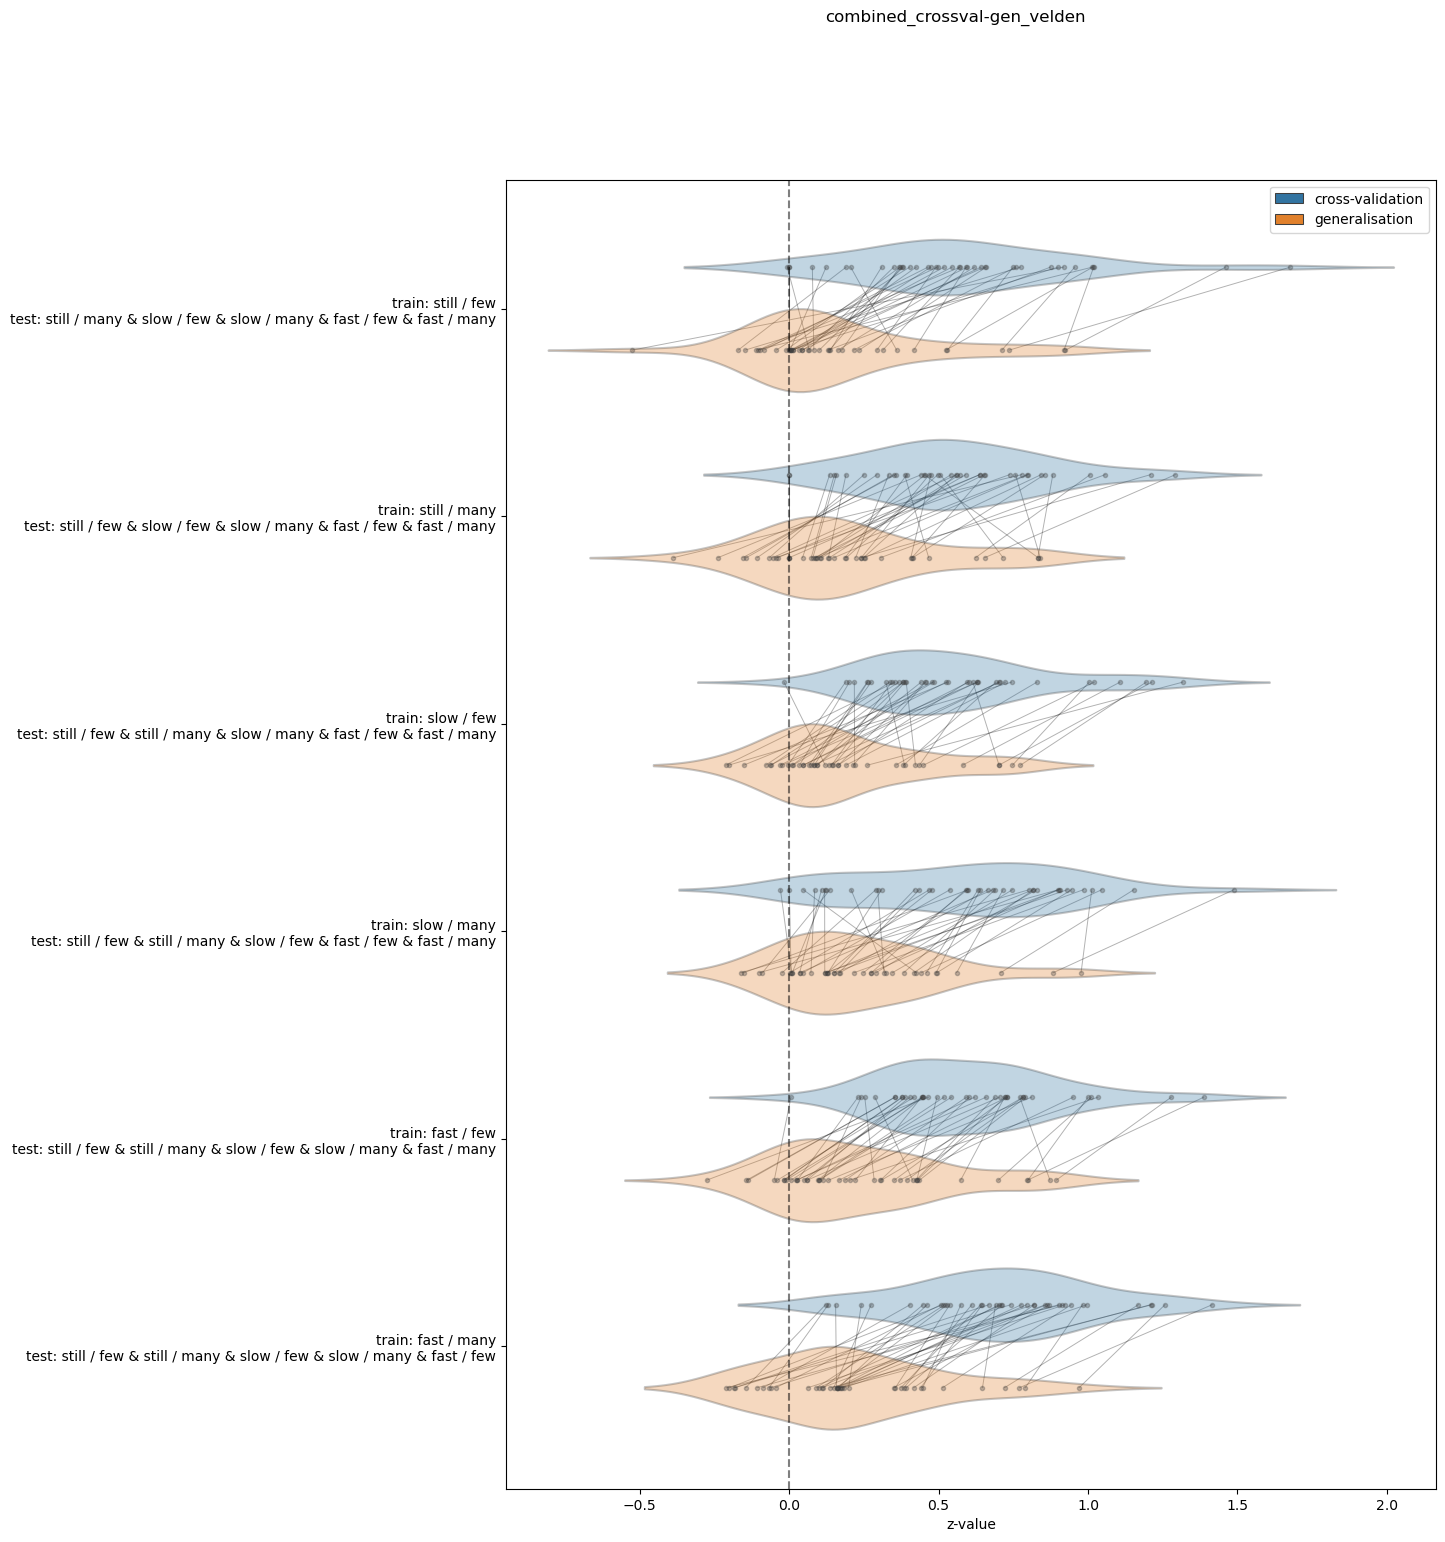

In [39]:
if show_validation_generalisation_plots or save_validation_generalisation_plots:
    
    # structur data and labels set wise
    testsetlabels_setwise = []
    testset_labels = create_setlabels(test_sets)
    dengen_trainingsetwise = []
    for trainset in range(0,6):
        # turn into list of trainingsets including list of testsets including list of subjects
        testset_data = []
        for testset in range(0,5):
            testset_data.append([subject[(trainset * 5) + testset] for subject in veldengen_setwise_zs])
        dengen_trainingsetwise.append(testset_data) 
        testsetlabels_setwise.extend([testset_labels[trainset*5:(trainset+1)*5]])
        
    # create training set labels
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    trainingset_labels = labels[list(np.sort(idx))]
    
    
    # average data for each training set
    labels = create_setlabels(training_sets)
    labels = np.array(labels)
    _, idx = np.unique(labels, return_index = True)
    unique_labels = labels[list(np.sort(idx))]
    
    set_averages = []
    for subject_zs in veldengen_setwise_zs:  
        subject_averages = []
        for label in unique_labels:
            idx = np.where(np.array(labels) == label)
            subject_averages.append(np.mean(subject_zs[idx]))
        set_averages.append(subject_averages)
    
    plot_validation_and_generalisation(validation_setwise_zs = veldencrossval_setwise_zs, generalisation_setwise_zs = set_averages,
                                       trainingset_labels = trainingset_labels,
                                       testset_labels = testsetlabels_setwise,
                                       connect_analyses = connect_analyses, connect_sets = connect_sets,
                                       title = "combined_crossval-gen_velden", show_plots = show_validation_generalisation_plots, save_plots = save_validation_generalisation_plots,
                                       figsize = (12, 17))

### 2.2.4 Generalisation RS
Test whether it is possible to predict PoTJs in RS with classifiers trained on starfield data

#### 2.2.4.1 Prediction test
Train classifiers to predict PoTJs from snapshot features using a part of the data from all conditions and test on the unseen part of data from all conditions

Before testing whether classifiers could generalize over different situations we first tested whether classifiers were at all able to predict PoTJs for known situations, i.e. known experimental conditions in a fivefold cross validation (Blum et al., 1999). 
To this end, for each subject, snapshots from all six possible combinations of condition levels (zero, slow and fast velocity / low and high density) were split into 5 folds with each fold containing equal amounts of snapshots per condition combination. Four of the five folds were then used to train a classifier (training-set) and the last fold was used to test the classifier (test-set). This was conducted for each subject separately and for each of the five possible combination of folds into training and test-set. Correlation coefficients were then z-transformed, averaged subject wise and tested against zero in a t-test.

In [40]:
if perform_new_generalisation:
    # Perform crossvalidation for each subject
    rs_subjectwise_corrs = generalisation_rs(subjects, compute_new_subject_results = compute_new_subject_results, use_saved_classifiers = use_saved_classifiers, save_subject_results = save_subject_results, save_group_results = save_group_results)
    # load stored crossvalidation results for the whole group
else:
    with open(path_study_data / 'group_level' / 'generalisation_rs.pkl', 'rb') as f:
        rs_subjectwise_corrs = pickle.load(f)

RS-Generalisation for subject 1
RS-Generalisation for subject 2
RS-Generalisation for subject 3
RS-Generalisation for subject 4
RS-Generalisation for subject 5
RS-Generalisation for subject 6
RS-Generalisation for subject 7
RS-Generalisation for subject 8
RS-Generalisation for subject 9
RS-Generalisation for subject 10
RS-Generalisation for subject 11
RS-Generalisation for subject 12
RS-Generalisation for subject 13
RS-Generalisation for subject 14
RS-Generalisation for subject 15
RS-Generalisation for subject 16
RS-Generalisation for subject 17
RS-Generalisation for subject 18
RS-Generalisation for subject 19
RS-Generalisation for subject 20
RS-Generalisation for subject 21
RS-Generalisation for subject 22
RS-Generalisation for subject 23
RS-Generalisation for subject 25
RS-Generalisation for subject 26
RS-Generalisation for subject 27
RS-Generalisation for subject 28
RS-Generalisation for subject 29
RS-Generalisation for subject 30
RS-Generalisation for subject 31
RS-Generalisation f

## 2.3 Validation and Checking

### 2.3.1 Overview of failed correlation computations

Checking how many generalisation tests failed per subject

In [41]:
missing_corrs_total = pd.DataFrame({"gen": [int(x) for x in general_missing_corrs],
                                    "v_c": vel_crossval_missing_corrs,
                                    "v_g": vel_gen_missing_corrs,
                                    "d_c": den_crossval_missing_corrs,
                                    "d_g": den_gen_missing_corrs,
                                    "v/d_c": velden_crossval_missing_corrs,
                                    "v/d_g": velden_gen_missing_corrs},
                                   index = subjects) 
           

print(f"Missing per subject:")
missing_corrs_total

Missing per subject:


,gen,v_c,v_g,d_c,d_g,v/d_c,v/d_g
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0
7,0,1,4,0,0,2,18
8,0,0,0,0,0,0,0
9,0,1,2,0,0,2,14
10,0,0,0,0,0,0,0


For two subjects ('007' and '009') some correlations between real and predicted PoTJs could not be computed with a 'constant input' warning message (meaning one of the two vectors does not have enough variance).

In order to ensure that this is realy based on the participants behavior we are going to plot PoTJ-ratings from all participants.

c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\jordingma\AppData\Local\anaconda3\envs\mne_updated\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

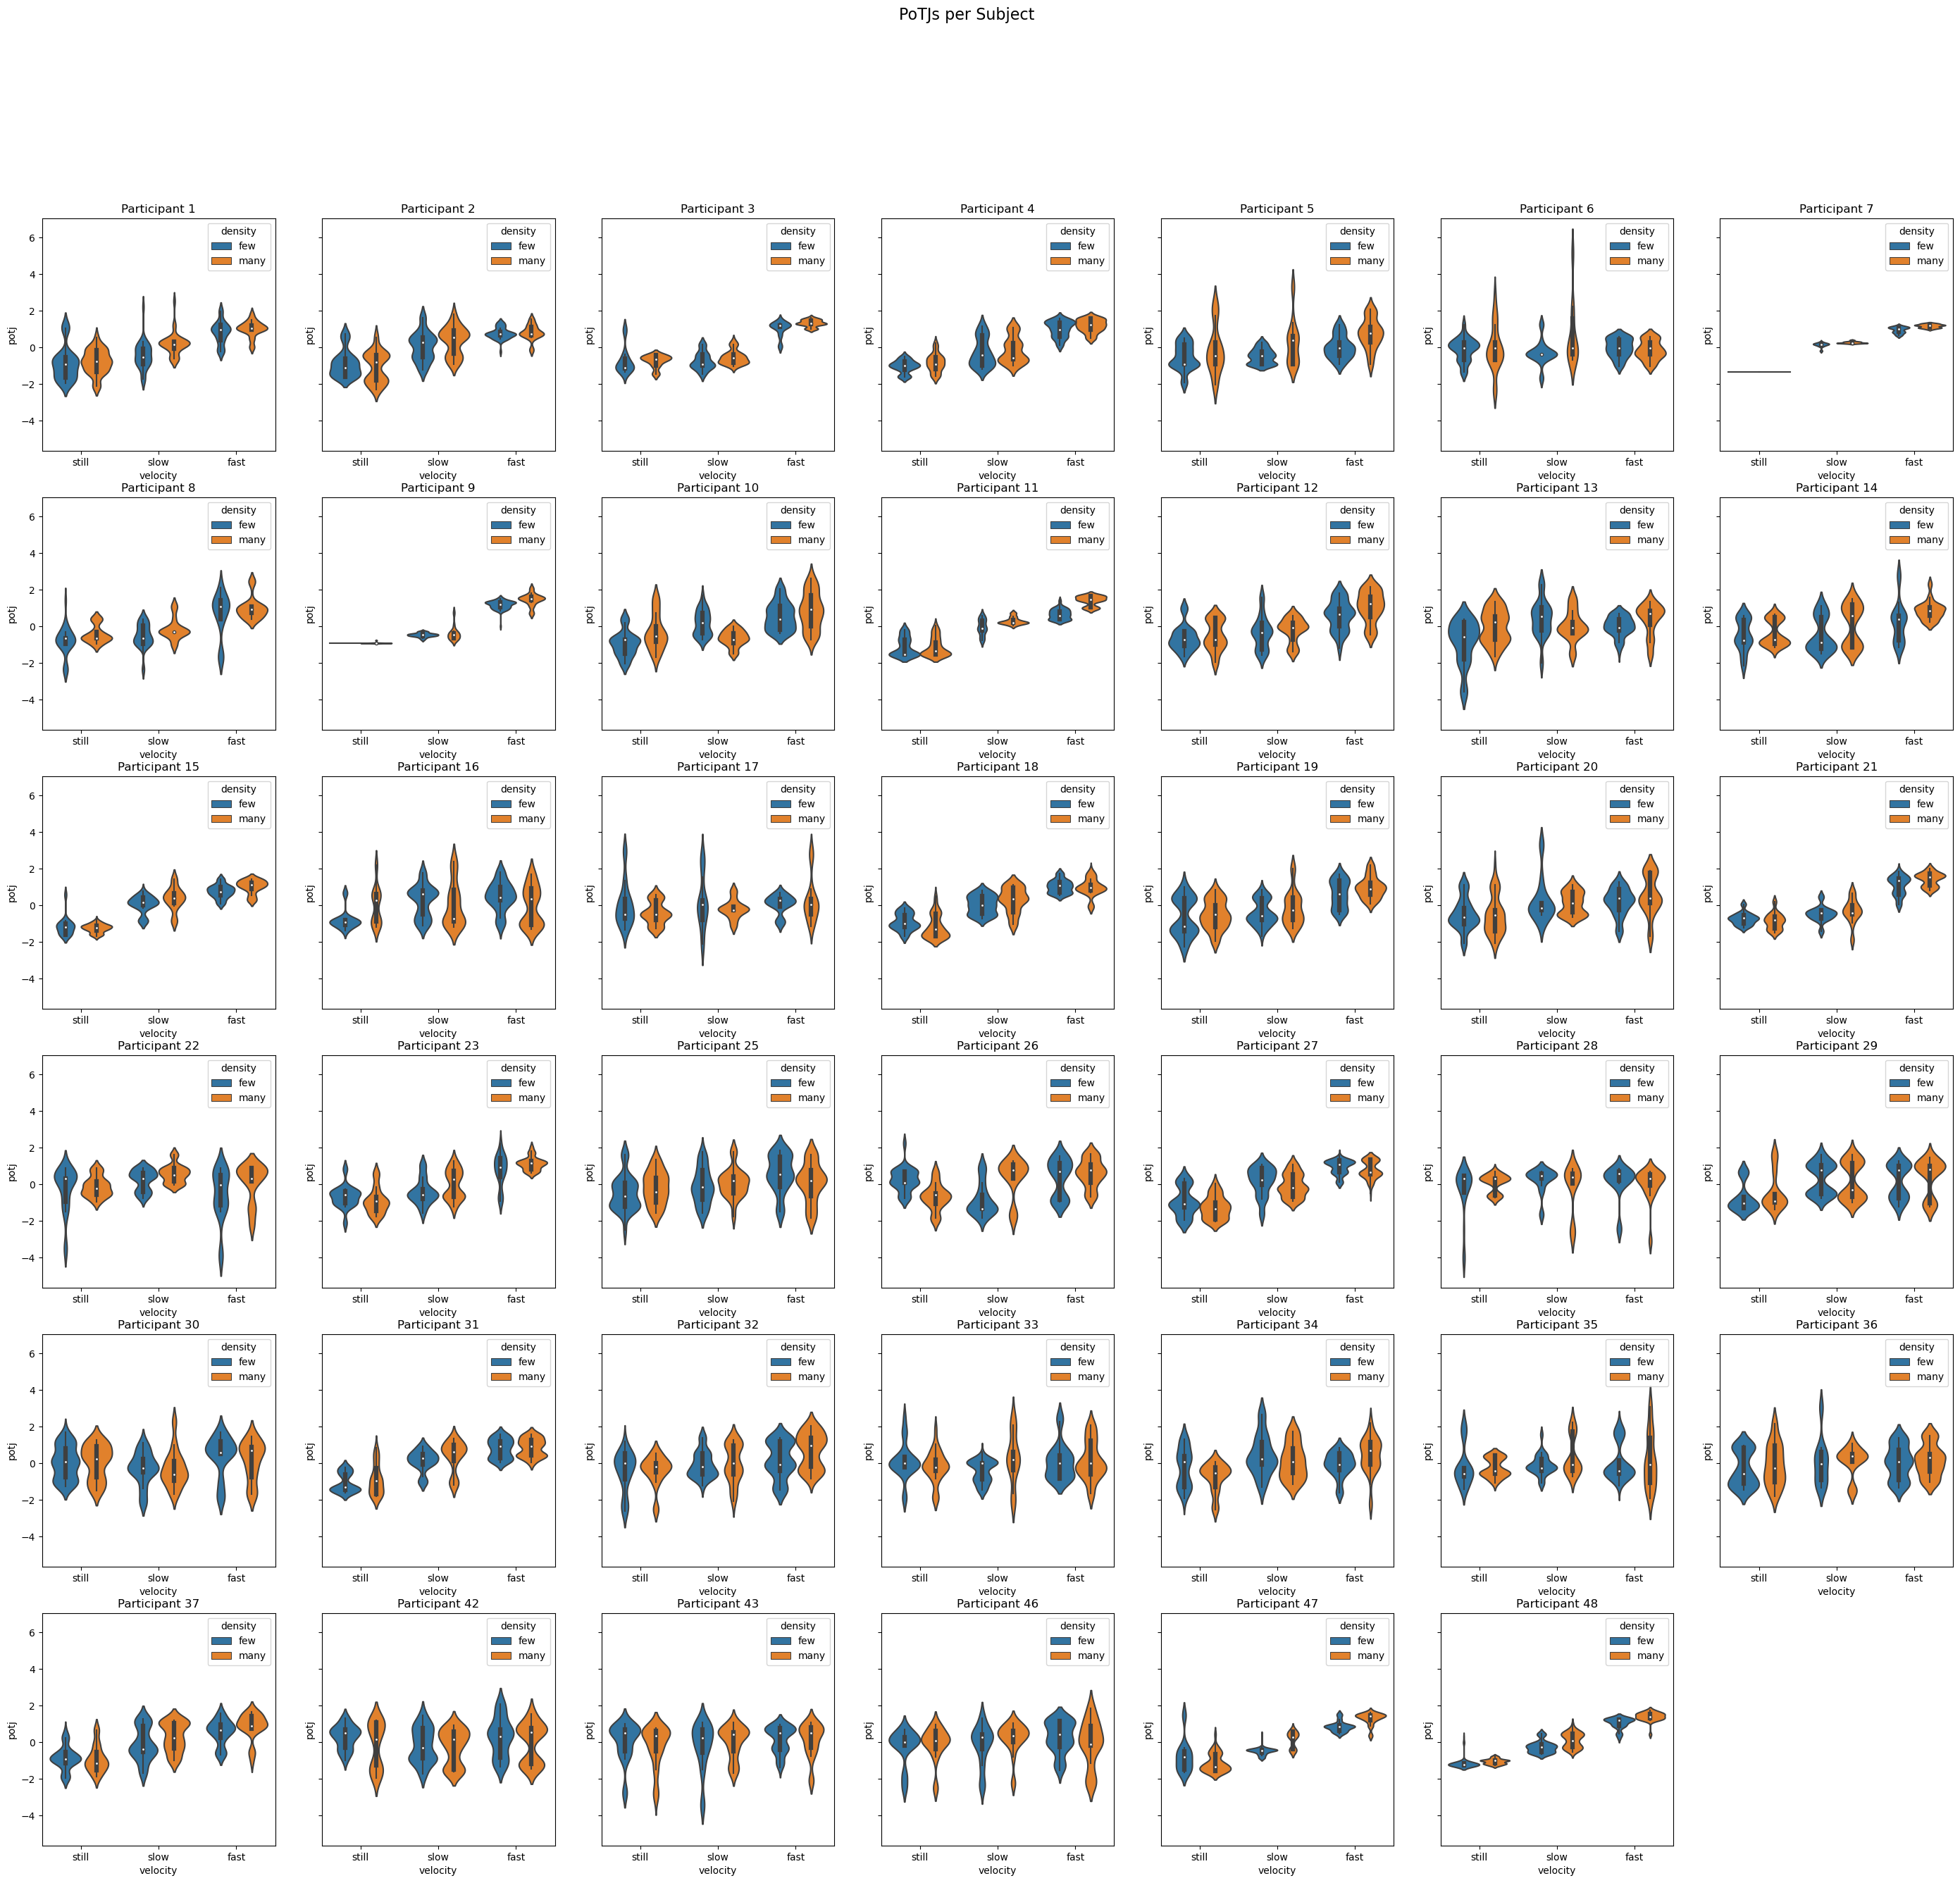

In [42]:
plot_subject_ratings(subjects, z_standardisation = True, show_plots = show_subjectwise_behavioral_plots, save_plots = save_subjectwise_behavioral_plots)

As visible from the plots, subjects '007' and '009' both show little to no variation in PoTJs in the velocity = 0 condition. This lack of variance is not visible in any of the other subjects.

### 2.3.2 Repeating analyses after participant exclusion

Repeat all groupwise t-tests with subjects '007' and '009' excluded

In [43]:
# build a vector listing which subjects to included
excluded_subjects = [7,9]
subject_inclusions = [subject not in excluded_subjects for subject in subjects]

print("Repeating analysis from 2.1.1 General prediciton test")
print(stats_to_str(sc.stats.ttest_1samp(general_subjectwise_zs[subject_inclusions], popmean = 0)))

print("")
print("-------------------------------------------------------------------------------------------------")
print("Repeating analysis from 2.2.1 Crossvalidation and generalisation tests between velocity conditions")
print(stats_to_str(sc.stats.ttest_1samp(velcrossval_subjectwise_zs[subject_inclusions], popmean = 0)))
print(stats_to_str(sc.stats.ttest_1samp(velgen_subjectwise_zs[subject_inclusions], popmean = 0)))
print("")

print("-------------------------------------------------------------------------------------------------")
print("Repeating analysis from 2.2.2 Crossvalidation and generalisation tests between density conditions")
print(stats_to_str(sc.stats.ttest_1samp(dencrossval_subjectwise_zs[subject_inclusions], popmean = 0)))
print(stats_to_str(sc.stats.ttest_1samp(dengen_subjectwise_zs[subject_inclusions], popmean = 0)))
print("")

print("-------------------------------------------------------------------------------------------------")
print("Repeating analysis from 2.2.3 Crossvalidation and generalisation tests between velocity-density condition combinations")
print(stats_to_str(sc.stats.ttest_1samp(veldencrossval_subjectwise_zs[subject_inclusions], popmean = 0)))
print(stats_to_str(sc.stats.ttest_1samp(veldengen_subjectwise_zs[subject_inclusions], popmean = 0)))

Repeating analysis from 2.1.1 General prediciton test
t(38) = 13.537, p < 0.001 ***

-------------------------------------------------------------------------------------------------
Repeating analysis from 2.2.1 Crossvalidation and generalisation tests between velocity conditions
t(38) = 14.108, p < 0.001 ***
t(38) = 4.749, p < 0.001 ***

-------------------------------------------------------------------------------------------------
Repeating analysis from 2.2.2 Crossvalidation and generalisation tests between density conditions
t(38) = 14.349, p < 0.001 ***
t(38) = 8.865, p < 0.001 ***

-------------------------------------------------------------------------------------------------
Repeating analysis from 2.2.3 Crossvalidation and generalisation tests between velocity-density condition combinations
t(38) = 17.496, p < 0.001 ***
t(38) = 4.987, p < 0.001 ***
